# H1 Baseline Without Building a Dense User × Property Matrix

This notebook implements the same **Steps 1 and 2** for Hypothesis 1, but in a **memory-safe sparse way**.

The earlier version failed because converting a very large user–property matrix to a dense pandas DataFrame would require tens of gigabytes of RAM.

This version avoids that by:

- keeping the data in **long format** as long as possible
- constructing a **SciPy sparse COO/CSR matrix** directly from integer-coded users and properties
- computing **TF-IDF on the sparse matrix**
- extracting only the **top-k values per user** instead of materializing the full dense TF-IDF matrix

This is the right approach because the user–property space is extremely sparse.


## Scientific goal

We want to assess H1:

> Some Wikidata users are **property specialists**, meaning they use globally rare properties much more often than the rest of the population.

We compute three baseline signals:

1. **TF-IDF**
   - users = documents
   - properties = terms

2. **Lift**
   - overrepresentation of a property within a user relative to the global baseline

3. **Entropy**
   - concentration of a user's property distribution

These measures can identify **candidate specialists** without clustering yet.


In [1]:
!pip install -U scikit-learn

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import sparse
from scipy.stats import entropy
from sklearn.feature_extraction.text import TfidfTransformer

pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)


## Step 0 — Load the long-format CSV


In [3]:
csv_path = Path("h1_user_property_counts.csv")
df = pd.read_csv(csv_path)

required = {"user", "property", "count"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}")

df["count"] = pd.to_numeric(df["count"], errors="raise")

print(f"Rows: {len(df):,}")
print(f"Users: {df['user'].nunique():,}")
print(f"Properties: {df['property'].nunique():,}")

#df.head()


Rows: 4,352,804
Users: 853,511
Properties: 12,730


In [4]:
df['count'].sum()

1653318091

## Step 1 — Build a sparse matrix directly from the long table

Instead of pivoting into a huge dense table, we:

- assign each user an integer row id
- assign each property an integer column id
- build a sparse matrix from `(row, col, count)`

This preserves the same mathematical representation while using memory proportional to the number of **nonzero observations**, not to the full number of possible cells.


In [5]:
# Aggregate just in case the CSV contains repeated (user, property) rows
agg = (
    df.groupby(["user", "property"], as_index=False)["count"]
      .sum()
)

# Integer codes
user_codes, user_index = pd.factorize(agg["user"], sort=True)
prop_codes, prop_index = pd.factorize(agg["property"], sort=True)

n_users = len(user_index)
n_props = len(prop_index)

X_counts = sparse.coo_matrix(
    (agg["count"].astype(np.float32), (user_codes, prop_codes)),
    shape=(n_users, n_props)
).tocsr()

print(f"Sparse count matrix shape: {X_counts.shape}")
print(f"Nonzero entries: {X_counts.nnz:,}")
print(f"Density: {X_counts.nnz / (X_counts.shape[0] * X_counts.shape[1]):.8f}")


Sparse count matrix shape: (853511, 12730)
Nonzero entries: 4,352,804
Density: 0.00040062


### Basic summaries without densifying


In [6]:
user_totals = np.asarray(X_counts.sum(axis=1)).ravel()
prop_totals = np.asarray(X_counts.sum(axis=0)).ravel()
prop_user_freq = np.asarray((X_counts > 0).sum(axis=0)).ravel()

summary = pd.DataFrame({
    "metric": [
        "n_users",
        "n_properties",
        "n_nonzero_cells",
        "matrix_density",
        "median_edits_per_user",
        "median_users_per_property"
    ],
    "value": [
        n_users,
        n_props,
        int(X_counts.nnz),
        X_counts.nnz / (X_counts.shape[0] * X_counts.shape[1]),
        float(np.median(user_totals)),
        float(np.median(prop_user_freq))
    ]
})

#summary


## Step 1a — Compute TF-IDF on the sparse matrix

This keeps the representation sparse throughout.


In [7]:
tfidf = TfidfTransformer(norm="l2", use_idf=True, smooth_idf=True, sublinear_tf=False)
X_tfidf = tfidf.fit_transform(X_counts)

print(X_tfidf.shape, X_tfidf.nnz)


(853511, 12730) 4352804


### Inspect globally rare properties using IDF


In [8]:
idf_table = pd.DataFrame({
    "property": prop_index,
    "idf": tfidf.idf_,
    "n_users_using_property": prop_user_freq,
    "total_count": prop_totals
}).sort_values(["idf", "n_users_using_property", "total_count"], ascending=[False, True, True])

idf_table.head(5)


,property,idf,n_users_using_property,total_count
97,P1009,13.963967,1,1.0
167,P10153,13.963967,1,1.0
219,P10201,13.963967,1,1.0
432,P10398,13.963967,1,1.0
434,P104,13.963967,1,1.0


## Extract top TF-IDF properties per user without converting to dense

For each user row in CSR format, we only inspect the nonzero values and keep the top-k entries.


In [9]:
def top_k_per_row_csr(X_csr, row_labels, col_labels, k=5, score_name="score"):
    rows = []
    for i in range(X_csr.shape[0]):
        start, end = X_csr.indptr[i], X_csr.indptr[i + 1]
        cols = X_csr.indices[start:end]
        vals = X_csr.data[start:end]

        if len(vals) == 0:
            continue

        take = min(k, len(vals))
        top_idx = np.argpartition(-vals, take - 1)[:take]
        order = top_idx[np.argsort(-vals[top_idx])]

        for rank, j in enumerate(order, start=1):
            rows.append({
                "user": row_labels[i],
                "rank": rank,
                "property": col_labels[cols[j]],
                score_name: float(vals[j])
            })
    return pd.DataFrame(rows)

top_tfidf_per_user = top_k_per_row_csr(
    X_tfidf, user_index, prop_index, k=5, score_name="tfidf"
)

top_tfidf_per_user.head(5)


,user,rank,property,tfidf
0,!Silent,1,P175,0.753448
1,!Silent,2,P577,0.556023
2,!Silent,3,P31,0.350933
3,!aoniug,1,P18,0.642252
4,!aoniug,2,P279,0.620169


## Step 2 — Specialist scores

### 2.1 Max TF-IDF per user

This is the strongest single specialist signal for each user.


In [10]:
max_tfidf = np.zeros(n_users, dtype=np.float32)
top_prop_idx = np.full(n_users, -1, dtype=np.int32)

for i in range(X_tfidf.shape[0]):
    start, end = X_tfidf.indptr[i], X_tfidf.indptr[i + 1]
    vals = X_tfidf.data[start:end]
    cols = X_tfidf.indices[start:end]
    if len(vals) == 0:
        continue
    j = np.argmax(vals)
    max_tfidf[i] = vals[j]
    top_prop_idx[i] = cols[j]

specialist_baseline = pd.DataFrame({
    "user": user_index,
    "max_tfidf": max_tfidf,
    "top_property_by_tfidf": [prop_index[j] if j >= 0 else None for j in top_prop_idx],
    "total_edits": user_totals
}).sort_values("max_tfidf", ascending=False)

specialist_baseline.head(5)


,user,max_tfidf,top_property_by_tfidf,total_edits
426755,2A02:2F01:8A00:7A00:1801:F07A:CD3:89CA,1.0,P22,1.0
461358,37.159.61.183,1.0,P856,2.0
461362,37.159.62.3,1.0,P6375,1.0
461363,37.159.62.36,1.0,P856,1.0
461364,37.159.62.71,1.0,P373,1.0


### 2.2 Lift without densifying

We compute:

- `P(property | user)` from each row's counts
- `P(property)` from the global property totals
- `lift = P(property | user) / P(property)`

Again, we compute only on nonzero entries.


In [11]:
global_prop_share = prop_totals / prop_totals.sum()

lift_rows = []

for i in range(X_counts.shape[0]):
    start, end = X_counts.indptr[i], X_counts.indptr[i + 1]
    cols = X_counts.indices[start:end]
    vals = X_counts.data[start:end].astype(np.float64)

    total = vals.sum()
    if total == 0:
        continue

    user_share = vals / total
    lift_vals = user_share / global_prop_share[cols]

    take = min(5, len(lift_vals))
    top_idx = np.argpartition(-lift_vals, take - 1)[:take]
    order = top_idx[np.argsort(-lift_vals[top_idx])]

    for rank, j in enumerate(order, start=1):
        lift_rows.append({
            "user": user_index[i],
            "rank": rank,
            "property": prop_index[cols[j]],
            "lift": float(lift_vals[j])
        })

top_lift_per_user = pd.DataFrame(lift_rows)
top_lift_per_user.head(5)


,user,rank,property,lift
0,!Silent,1,P175,946.137423
1,!Silent,2,P577,12.048804
2,!Silent,3,P31,4.705992
3,!aoniug,1,P18,109.703444
4,!aoniug,2,P279,70.451839


### 2.3 Entropy without densifying

Low entropy indicates concentrated property use.


In [12]:
entropy_bits = np.zeros(n_users, dtype=np.float32)

for i in range(X_counts.shape[0]):
    start, end = X_counts.indptr[i], X_counts.indptr[i + 1]
    vals = X_counts.data[start:end].astype(np.float64)
    total = vals.sum()
    if total == 0:
        entropy_bits[i] = np.nan
        continue
    probs = vals / total
    entropy_bits[i] = entropy(probs, base=2)

specialist_scores = pd.DataFrame({
    "user": user_index,
    "max_tfidf": max_tfidf,
    "top_property_by_tfidf": [prop_index[j] if j >= 0 else None for j in top_prop_idx],
    "entropy_bits": entropy_bits,
    "total_edits": user_totals
}).sort_values(["max_tfidf", "entropy_bits"], ascending=[False, True])

specialist_scores.head(5)


,user,max_tfidf,top_property_by_tfidf,entropy_bits,total_edits
12,"""femilation""",1.0,P856,0.0,1.0
13,"""giancarlo sav""",1.0,P1352,0.0,1.0
18,"""pedran444""",1.0,P161,0.0,1.0
23,$q38jd,1.0,P31,0.0,1.0
24,$toic,1.0,P373,0.0,4.0


## Candidate specialists

A practical filter is:

- reasonably high edit count
- high max TF-IDF
- low entropy


In [13]:
min_total_edits = 5

candidate_specialists = specialist_scores.loc[
    specialist_scores["total_edits"] >= min_total_edits
].copy()

candidate_specialists = candidate_specialists.sort_values(
    ["max_tfidf", "entropy_bits", "total_edits"],
    ascending=[False, True, False]
)

#candidate_specialists.head(30)


## Combine top TF-IDF and top lift explanations


In [14]:
top_tfidf_rank1 = (
    top_tfidf_per_user.query("rank == 1")[["user", "property", "tfidf"]]
    .rename(columns={"property": "top_tfidf_property", "tfidf": "top_tfidf_value"})
)

top_lift_rank1 = (
    top_lift_per_user.query("rank == 1")[["user", "property", "lift"]]
    .rename(columns={"property": "top_lift_property", "lift": "top_lift_value"})
)

report_table = (
    candidate_specialists
    .merge(top_tfidf_rank1, on="user", how="left")
    .merge(top_lift_rank1, on="user", how="left")
)

#report_table.head(30)


## Why this works better

The key difference is that this notebook never does:

- `pivot_table(...)` into a huge dense frame
- `X_tfidf.toarray()`

Those two operations are what caused the memory error.

This version is appropriate for very large sparse interaction data.


## Optional export


In [15]:
output_path = Path("h1_candidate_specialists_sparse.csv")
report_table.to_csv(output_path, index=False)
print(f"Saved: {output_path.resolve()}")


Saved: /home/jovyan/work/wd_history_full_paper/h1/h1_candidate_specialists_sparse.csv


# Next Steps:

- There are many fake "specialists" with one singel edit only, ip addresses, and bots specialized on a single property.
- we will filter these and see if we can find relevant communities

#### 1. Load the bot list and define filter parameters

In [16]:
import json
import numpy as np
import pandas as pd
import ipaddress
from pathlib import Path

# ---- PARAMETERS ----
REMOVE_IP_USERS = True
REMOVE_BOTS = True
MIN_TOTAL_EDITS_PER_USER = 3
MIN_USERS_PER_PROPERTY = 5
MIN_DISTINCT_PROPERTIES_PER_USER = 2

# Optional fallback: also remove usernames containing "bot"
USE_BOT_NAME_FALLBACK = True

# Load curated bot list
bots_path = Path("wikidata_bots.json")
with open(bots_path, "r", encoding="utf-8") as f:
    bot_list = json.load(f)

bot_set = set(bot_list)

print(f"Loaded {len(bot_set):,} bot names from {bots_path}")
print("Filtering parameters:")
print(f"  REMOVE_IP_USERS = {REMOVE_IP_USERS}")
print(f"  REMOVE_BOTS = {REMOVE_BOTS}")
print(f"  MIN_TOTAL_EDITS_PER_USER = {MIN_TOTAL_EDITS_PER_USER}")
print(f"  MIN_USERS_PER_PROPERTY = {MIN_USERS_PER_PROPERTY}")
print(f"  MIN_DISTINCT_PROPERTIES_PER_USER = {MIN_DISTINCT_PROPERTIES_PER_USER}")
print(f"  USE_BOT_NAME_FALLBACK = {USE_BOT_NAME_FALLBACK}")

Loaded 306 bot names from wikidata_bots.json
Filtering parameters:
  REMOVE_IP_USERS = True
  REMOVE_BOTS = True
  MIN_TOTAL_EDITS_PER_USER = 3
  MIN_USERS_PER_PROPERTY = 5
  MIN_DISTINCT_PROPERTIES_PER_USER = 2
  USE_BOT_NAME_FALLBACK = True


In [17]:
## Helper
def is_ip_username(name):
    """
    Return True if the username is an IPv4 or IPv6 address, else False.
    """
    try:
        ipaddress.ip_address(str(name))
        return True
    except ValueError:
        return False


def snapshot(stage_name, frame):
    return {
        "stage": stage_name,
        "rows": int(len(frame)),
        "users": int(frame["user"].nunique()),
        "properties": int(frame["property"].nunique()),
        "total_edits": float(frame["count"].sum())
    }

#### 2. Start from the long table and create a reusable snapshot helper

In [18]:
agg0 = (
    df.groupby(["user", "property"], as_index=False)["count"]
      .sum()
)

filter_log = [snapshot("raw", agg0)]

print("Initial dataset:")
print(filter_log[-1])

Initial dataset:
{'stage': 'raw', 'rows': 4352804, 'users': 853511, 'properties': 12730, 'total_edits': 1653318091.0}


#### 3. Apply filters step by step

In [19]:
# -------------------------
# 1) Remove anonymous IP users
# -------------------------
agg1 = agg0.copy()

if REMOVE_IP_USERS:
    raw_users = pd.Index(agg1["user"].unique())
    ip_users = raw_users[[is_ip_username(u) for u in raw_users]]
    agg1 = agg1[~agg1["user"].isin(ip_users)].copy()
else:
    ip_users = pd.Index([])

filter_log.append(snapshot("after_ip_filter", agg1))

print(f"IP users detected: {len(ip_users):,}")


# -------------------------
# 2) Remove bots using curated bot list
# -------------------------
agg2 = agg1.copy()

if REMOVE_BOTS:
    users2 = pd.Index(agg2["user"].unique())
    bot_mask = users2.isin(bot_set)

    ## ENDSWTIH BOT
    if USE_BOT_NAME_FALLBACK:
        bot_mask = bot_mask | users2.to_series().str.lower().str.endswith(
            "bot", na=False
        ).values

    bot_users_found = users2[bot_mask]
    agg2 = agg2[~agg2["user"].isin(bot_users_found)].copy()
else:
    bot_users_found = pd.Index([])

filter_log.append(snapshot("after_bot_filter", agg2))

print(f"Bots removed: {len(bot_users_found):,}")


# -------------------------
# 3) Keep only properties used by at least MIN_USERS_PER_PROPERTY users
# -------------------------
agg3 = agg2.copy()

prop_support2 = agg3.groupby("property")["user"].nunique()
keep_props = prop_support2[prop_support2 >= MIN_USERS_PER_PROPERTY].index
agg3 = agg3[agg3["property"].isin(keep_props)].copy()

filter_log.append(snapshot("after_min_property_users", agg3))

print(f"Properties used by >= {MIN_USERS_PER_PROPERTY} users kept: {len(keep_props):,}")


# -------------------------
# 4) Keep only users with at least MIN_TOTAL_EDITS_PER_USER edits
# -------------------------
agg4 = agg3.copy()

user_totals3 = agg4.groupby("user")["count"].sum()
keep_users = user_totals3[user_totals3 >= MIN_TOTAL_EDITS_PER_USER].index
agg4 = agg4[agg4["user"].isin(keep_users)].copy()

filter_log.append(snapshot("after_min_user_edits", agg4))

print(f"Users with >= {MIN_TOTAL_EDITS_PER_USER} edits kept: {len(keep_users):,}")


# -------------------------
# 5) Keep only users with at least MIN_DISTINCT_PROPERTIES_PER_USER distinct properties
# -------------------------
agg5 = agg4.copy()

user_property_support4 = agg5.groupby("user")["property"].nunique()
keep_users_multi = user_property_support4[
    user_property_support4 >= MIN_DISTINCT_PROPERTIES_PER_USER
].index
agg5 = agg5[agg5["user"].isin(keep_users_multi)].copy()

filter_log.append(snapshot("after_min_distinct_properties_per_user", agg5))

print(
    f"Users with >= {MIN_DISTINCT_PROPERTIES_PER_USER} distinct properties kept: "
    f"{len(keep_users_multi):,}"
)

IP users detected: 674,714
Bots removed: 689
Properties used by >= 5 users kept: 9,667
Users with >= 3 edits kept: 111,362
Users with >= 2 distinct properties kept: 104,419


In [20]:
agg_filtered = agg5.copy()
agg = agg_filtered.copy()

print("Final filtered dataset:")
print(snapshot("final", agg_filtered))

Final filtered dataset:
{'stage': 'final', 'rows': 2610544, 'users': 104419, 'properties': 9667, 'total_edits': 623634350.0}


#### quantify

In [21]:
filter_summary = pd.DataFrame(filter_log)

for col in ["rows", "users", "properties", "total_edits"]:
    baseline = filter_summary.loc[0, col]
    filter_summary[f"{col}_removed"] = baseline - filter_summary[col]
    filter_summary[f"{col}_removed_pct"] = np.where(
        baseline > 0,
        100 * (baseline - filter_summary[col]) / baseline,
        np.nan
    )

filter_summary

,stage,rows,users,properties,total_edits,rows_removed,rows_removed_pct,users_removed,users_removed_pct,properties_removed,properties_removed_pct,total_edits_removed,total_edits_removed_pct
0,raw,4352804,853511,12730,1.653318e+09,0,0.000000,0,0.000000,0,0.000000,0.000000e+00,0.000000
1,after_ip_filter,2726263,178797,12711,1.648717e+09,1626541,37.367660,674714,79.051588,19,0.149254,4.601235e+06,0.278303
2,after_bot_filter,2704658,178108,12703,6.256845e+08,1648146,37.864007,675403,79.132313,27,0.212097,1.027634e+09,62.155832
3,after_min_property_users,2697218,178093,9667,6.240004e+08,1655586,38.034931,675418,79.134071,3063,24.061273,1.029318e+09,62.257690
4,after_min_user_edits,2617487,111362,9667,6.239133e+08,1735317,39.866647,742149,86.952482,3063,24.061273,1.029405e+09,62.262958
5,after_min_distinct_properties_per_user,2610544,104419,9667,6.236344e+08,1742260,40.026153,749092,87.765946,3063,24.061273,1.029684e+09,62.279833


#### compact report

In [22]:
compact_filter_report = filter_summary[[
    "stage",
    "users", "users_removed_pct",
    "properties", "properties_removed_pct",
    "rows", "rows_removed_pct",
    "total_edits", "total_edits_removed_pct"
]].copy()

compact_filter_report

,stage,users,users_removed_pct,properties,properties_removed_pct,rows,rows_removed_pct,total_edits,total_edits_removed_pct
0,raw,853511,0.000000,12730,0.000000,4352804,0.000000,1.653318e+09,0.000000
1,after_ip_filter,178797,79.051588,12711,0.149254,2726263,37.367660,1.648717e+09,0.278303
2,after_bot_filter,178108,79.132313,12703,0.212097,2704658,37.864007,6.256845e+08,62.155832
3,after_min_property_users,178093,79.134071,9667,24.061273,2697218,38.034931,6.240004e+08,62.257690
4,after_min_user_edits,111362,86.952482,9667,24.061273,2617487,39.866647,6.239133e+08,62.262958
5,after_min_distinct_properties_per_user,104419,87.765946,9667,24.061273,2610544,40.026153,6.236344e+08,62.279833


#### Human-readable summary

In [23]:
raw = filter_summary.iloc[0]
final = filter_summary.iloc[-1]

print("=== FILTER IMPACT SUMMARY ===")
print(f"Users:      {int(raw['users']):,} -> {int(final['users']):,} ({final['users_removed_pct']:.2f}% removed)")
print(f"Properties: {int(raw['properties']):,} -> {int(final['properties']):,} ({final['properties_removed_pct']:.2f}% removed)")
print(f"Rows:       {int(raw['rows']):,} -> {int(final['rows']):,} ({final['rows_removed_pct']:.2f}% removed)")
print(f"Edits:      {int(raw['total_edits']):,} -> {int(final['total_edits']):,} ({final['total_edits_removed_pct']:.2f}% removed)")

=== FILTER IMPACT SUMMARY ===
Users:      853,511 -> 104,419 (87.77% removed)
Properties: 12,730 -> 9,667 (24.06% removed)
Rows:       4,352,804 -> 2,610,544 (40.03% removed)
Edits:      1,653,318,091 -> 623,634,350 (62.28% removed)


#### Extra diagnostics: how many IPs and bots were present in raw data

In [24]:
raw_users = pd.Index(agg0["user"].unique())

raw_ip_users = raw_users[[is_ip_username(u) for u in raw_users]]
raw_bot_users = raw_users[raw_users.isin(bot_set)]

print(f"Anonymous IP users in raw data: {len(raw_ip_users):,}")
print(f"Curated bots in raw data: {len(raw_bot_users):,}")

if USE_BOT_NAME_FALLBACK:
    fallback_bot_users = raw_users[
        raw_users.to_series().str.contains("bot", case=False, regex=False, na=False).values
    ]
    print(f'Users matching fallback "bot" pattern: {len(fallback_bot_users):,}')

Anonymous IP users in raw data: 674,714
Curated bots in raw data: 256
Users matching fallback "bot" pattern: 909


#### Distinct-properties diagnostic

In [25]:
user_distinct_props = agg.groupby("user")["property"].nunique()
user_total_edits = agg.groupby("user")["count"].sum()

diagnostic = pd.DataFrame({
    "total_edits": user_total_edits,
    "distinct_properties": user_distinct_props
})

diagnostic.describe(percentiles=[0.5, 0.9, 0.99])

,total_edits,distinct_properties
count,1.044190e+05,104419.000000
mean,5.972422e+03,25.000661
std,4.028635e+05,73.350099
min,3.000000e+00,2.000000
50%,1.500000e+01,8.000000
90%,4.770000e+02,48.000000
99%,3.371224e+04,316.000000
max,1.111844e+08,3019.000000


#### Rebuild the sparse matrix from the filtered dataset

In [26]:
from scipy import sparse
from sklearn.feature_extraction.text import TfidfTransformer

user_codes, user_index = pd.factorize(agg["user"], sort=True)
prop_codes, prop_index = pd.factorize(agg["property"], sort=True)

n_users = len(user_index)
n_props = len(prop_index)

X_counts = sparse.coo_matrix(
    (agg["count"].astype(np.float32), (user_codes, prop_codes)),
    shape=(n_users, n_props)
).tocsr()

print(f"Sparse count matrix shape: {X_counts.shape}")
print(f"Nonzero entries: {X_counts.nnz:,}")
print(f"Density: {X_counts.nnz / (X_counts.shape[0] * X_counts.shape[1]):.8f}")

Sparse count matrix shape: (104419, 9667)
Nonzero entries: 2,610,544
Density: 0.00258619


#### 0. Make sure we use the filtered data

In [27]:
agg = agg_filtered.copy()

#### 1. Rebuild sparse matrix (same as before)

In [28]:
from scipy import sparse
from sklearn.feature_extraction.text import TfidfTransformer
import numpy as np

# Encode users and properties
user_codes, user_index = pd.factorize(agg["user"], sort=True)
prop_codes, prop_index = pd.factorize(agg["property"], sort=True)

n_users = len(user_index)
n_props = len(prop_index)

X_counts = sparse.coo_matrix(
    (agg["count"].astype(np.float32), (user_codes, prop_codes)),
    shape=(n_users, n_props)
).tocsr()

print(f"Matrix: {X_counts.shape}, nnz={X_counts.nnz:,}")

Matrix: (104419, 9667), nnz=2,610,544


#### 2. TF-IDF

In [29]:
tfidf = TfidfTransformer(norm="l2", use_idf=True)
X_tfidf = tfidf.fit_transform(X_counts)

#### Top TF-IDF per user

In [30]:
def top_k_per_user(X, k=5):
    rows = []
    for i in range(X.shape[0]):
        start, end = X.indptr[i], X.indptr[i+1]
        vals = X.data[start:end]
        cols = X.indices[start:end]

        if len(vals) == 0:
            continue

        idx = np.argsort(-vals)[:k]

        for rank, j in enumerate(idx, 1):
            rows.append({
                "user": user_index[i],
                "property": prop_index[cols[j]],
                "tfidf": float(vals[j]),
                "rank": rank
            })

    return pd.DataFrame(rows)

top_tfidf = top_k_per_user(X_tfidf, k=5)
top_tfidf.head(20)

,user,property,tfidf,rank
0,!Silent,P175,0.792922,1
1,!Silent,P577,0.540661,2
2,!Silent,P31,0.280999,3
3,!aoniug,P18,0.628628,1
4,!aoniug,P279,0.611059,2
5,!aoniug,P646,0.393987,3
6,!aoniug,P373,0.276057,4
7,!d'O Magriço valho,P570,0.611709,1
8,!d'O Magriço valho,P569,0.606204,2
9,!d'O Magriço valho,P571,0.429466,3


#### 3 Max TF-IDF per user

In [31]:
max_tfidf = np.zeros(n_users)
top_prop = np.full(n_users, -1)

for i in range(n_users):
    start, end = X_tfidf.indptr[i], X_tfidf.indptr[i+1]
    vals = X_tfidf.data[start:end]
    cols = X_tfidf.indices[start:end]

    if len(vals) == 0:
        continue

    j = np.argmax(vals)
    max_tfidf[i] = vals[j]
    top_prop[i] = cols[j]

tfidf_summary = pd.DataFrame({
    "user": user_index,
    "max_tfidf": max_tfidf,
    "top_property": [prop_index[j] if j >= 0 else None for j in top_prop]
})

tfidf_summary.sort_values("max_tfidf", ascending=False).head(10)

,user,max_tfidf,top_property
52964,Lewoniewski,1.0,P106
67238,Nonodename,1.0,P3347
37693,HeijnaA,1.0,P2861
91539,Tpd13,1.0,P9338
62666,Moiikke,1.0,P348
69523,Ostapt,1.0,P8179
95851,WT BEE,1.0,P2949
57105,Manducus,1.0,P6108
24662,Dr vulpes,1.0,P3648
89,.laramar.,1.0,P3762


#### 4. Lift (now VERY important)

In [32]:
# global distribution
prop_totals = np.asarray(X_counts.sum(axis=0)).ravel()
global_share = prop_totals / prop_totals.sum()

lift_rows = []

for i in range(n_users):
    start, end = X_counts.indptr[i], X_counts.indptr[i+1]
    vals = X_counts.data[start:end]
    cols = X_counts.indices[start:end]

    total = vals.sum()
    if total == 0:
        continue

    user_share = vals / total
    lift = user_share / global_share[cols]

    idx = np.argsort(-lift)[:5]

    for rank, j in enumerate(idx, 1):
        lift_rows.append({
            "user": user_index[i],
            "property": prop_index[cols[j]],
            "lift": float(lift[j]),
            "rank": rank
        })

top_lift = pd.DataFrame(lift_rows)
#top_lift.head(20)

#### 5. Entropy

In [33]:
from scipy.stats import entropy

entropy_vals = np.zeros(n_users)

for i in range(n_users):
    start, end = X_counts.indptr[i], X_counts.indptr[i+1]
    vals = X_counts.data[start:end]

    total = vals.sum()
    if total == 0:
        entropy_vals[i] = np.nan
        continue

    probs = vals / total
    entropy_vals[i] = entropy(probs, base=2)

entropy_df = pd.DataFrame({
    "user": user_index,
    "entropy": entropy_vals
})

#### 6. Combine everything

In [34]:
user_totals = np.asarray(X_counts.sum(axis=1)).ravel()

summary = (
    tfidf_summary
    .merge(entropy_df, on="user")
)

summary["total_edits"] = user_totals

# add top lift
top_lift1 = top_lift[top_lift["rank"] == 1][["user", "property", "lift"]]
top_lift1 = top_lift1.rename(columns={"property": "top_lift_property"})

summary = summary.merge(top_lift1, on="user", how="left")

summary.sort_values(["max_tfidf", "entropy"], ascending=[False, True]).head(30)

,user,max_tfidf,top_property,entropy,total_edits,top_lift_property,lift
67520,NowItem,1.0,P373,0.000183,98299.0,P373,231.336868
52964,Lewoniewski,1.0,P106,0.000879,17688.0,P106,66.537163
47373,KISTI Data,1.0,P13092,0.001028,31910.0,P13092,19177.044922
69523,Ostapt,1.0,P8179,0.001296,11524.0,P8179,5309.556641
57105,Manducus,1.0,P6108,0.002127,22423.0,P6108,3254.293213
91539,Tpd13,1.0,P9338,0.002350,12846.0,P9338,28284.054688
6894,Angeldeb82,1.0,P348,0.002779,4933.0,P348,939.286377
51442,Ladyartandarchitecture,1.0,P180,0.002877,4746.0,P180,866.353394
95661,Vuorje,1.0,P1741,0.002989,4548.0,P1741,21561.087891
61672,Minak,1.0,P8172,0.003848,38478.0,P8172,11530.639648


#### We removed bots using a curated bot list. Separately, we identified 25 users with extremely concentrated high-volume behavior (entropy < 0.01 and total_edits > 1000). Because many of these appear to be genuine human or organizational specialists rather than bots, we do not remove them by default; instead, we treat them as a flagged subset for robustness analysis.

In [35]:
summary

,user,max_tfidf,top_property,entropy,total_edits,top_lift_property,lift
0,!Silent,0.792922,P175,1.584963,3.0,P175,460.565552
1,!aoniug,0.628628,P18,1.842371,7.0,P279,63.653198
2,!d'O Magriço valho,0.611709,P570,2.774715,59.0,P5604,150997.359375
3,!dea4u,0.597635,P1889,2.855388,12.0,P2397,482.102661
4,!egamahendra,0.453686,P131,2.803950,83.0,P8626,27222.763672
...,...,...,...,...,...,...,...
104414,Ｔｏｍ,0.962712,P18,1.225236,25.0,P154,436.669800
104415,𐌰𐌹𐍂𐌼𐌹𐌽𐌰𐍂𐌴𐌹𐌺𐍃,0.401606,P94,4.180737,49.0,P94,234.193253
104416,𐰇𐱅𐰚𐰤,0.578296,P2448,5.793776,397.0,P7450,45663.632812
104417,🄱🄽🅆🄸🄺🄸 🅂🅂🄱,0.535417,P625,2.000000,4.0,P571,57.393703


In [36]:
summary[
    ((summary["entropy"] < 0.01) & (summary["total_edits"] > 1000))
]["user"]

89                     .laramar.
6894                  Angeldeb82
15064                      C1PB8
21165               Daniel Bonin
26970          Elhuyar Fundazioa
31505             Footballdigest
32032                Freakymovie
37693                    HeijnaA
46202            Jousep Bernhard
47373                 KISTI Data
51442     Ladyartandarchitecture
52964                Lewoniewski
57105                   Manducus
61672                      Minak
62666                    Moiikke
67520                    NowItem
69523                     Ostapt
82637                  Sgerginov
86210                   Steinsky
90188              Thomasstjerne
91539                      Tpd13
94444                VerifyToday
95661                     Vuorje
95851                     WT BEE
103668                   人造コケッコー
Name: user, dtype: object

### Flagging

In [37]:
known_bot_users = set(bot_set) & set(summary["user"])
extreme_users = set(summary.loc[
    (summary["entropy"] < 0.01) & (summary["total_edits"] > 1000),
    "user"
])

summary["known_bot_flag"] = summary["user"].isin(known_bot_users)
summary["extreme_specialist_flag"] = summary["user"].isin(extreme_users)

In [38]:
summary.head(20)

,user,max_tfidf,top_property,entropy,total_edits,top_lift_property,lift,known_bot_flag,extreme_specialist_flag
0,!Silent,0.792922,P175,1.584963,3.0,P175,460.565552,False,False
1,!aoniug,0.628628,P18,1.842371,7.0,P279,63.653198,False,False
2,!d'O Magriço valho,0.611709,P570,2.774715,59.0,P5604,150997.359375,False,False
3,!dea4u,0.597635,P1889,2.855388,12.0,P2397,482.102661,False,False
4,!egamahendra,0.453686,P131,2.803950,83.0,P8626,27222.763672,False,False
5,!болит,0.941651,P348,3.020093,920.0,P1972,20285.261719,False,False
6,"""BrumeEzewu22",0.663743,P4139,3.584963,12.0,P4139,558798.437500,False,False
7,"""Fish & Chip"" flavoured ice cream",0.655557,P12011,2.321928,10.0,P12011,228431.906250,False,False
8,"""Jhony777""",0.432886,P1303,3.884184,20.0,P6914,35554.109375,False,False
9,"""Yahia""",0.727877,P704,4.809322,61.0,P354,14238.527344,False,False


In [39]:
len(summary)

104419

## Preparing for baseline: cluster with hdbscan and tf-idf

In [40]:
print(X_tfidf.shape)
print(len(user_index))
print(len(agg_filtered["user"].unique()))

(104419, 9667)
104419
104419


#### Reducing dimensions

In [41]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(X_tfidf)

print(X_reduced.shape)

(104419, 100)


#### Clustering with hdbscan

In [42]:
!pip install hdbscan

## Description:

- We are clustering users based on the properties they edit, each cluster represents a group of users who edit a similar set of properties

In [43]:
from joblib import dump, load, Memory
import hdbscan

# optional: cache intermediate tree computation on disk
memory = Memory("./hdbscan_cache", verbose=0)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=100,
    metric="euclidean",
    cluster_selection_method="eom",
    core_dist_n_jobs=-1,   # use all available CPU cores for core-distance work
    memory=memory,         # cache expensive intermediate results on disk
)

labels = clusterer.fit_predict(X_reduced)

# save outputs for later reuse
dump(clusterer, "hdbscan_clusterer.joblib")
dump(labels, "hdbscan_labels.joblib")

['hdbscan_labels.joblib']

In [44]:
pd.Series(labels).value_counts().head(10)

-1     94637
 22     4616
 23      660
 10      552
 6       340
 17      322
 13      256
 14      255
 18      232
 11      223
dtype: int64

#### top properties per cluster

In [45]:
import numpy as np

def top_properties(cluster_id, top_n=10):
    idx = np.where(labels == cluster_id)[0]
    
    if len(idx) == 0:
        return []
    
    mean_vec = X_tfidf[idx].mean(axis=0).A1
    top_idx = np.argsort(-mean_vec)[:top_n]
    
    return [prop_index[i] for i in top_idx]

In [46]:
cluster_id = 22

In [47]:
print(f"Cluster {cluster_id} size:", (labels == cluster_id).sum())
print(top_properties(cluster_id))

Cluster 22 size: 4616
['P31', 'P18', 'P5831', 'P2949', 'P1352', 'P5185', 'P1552', 'P729', 'P274', 'P948']


In [48]:
def analyze_cluster(cluster_id, top_n=10):
    import numpy as np
    import pandas as pd

    idx = np.where(labels == cluster_id)[0]
    users = user_index[idx]

    # subset of agg
    sub = agg[agg["user"].isin(users)]

    n_users = len(users)

    # property usage
    prop_user_counts = sub.groupby("property")["user"].nunique()
    prop_total_counts = sub.groupby("property")["count"].sum()

    # global usage (for comparison)
    global_user_counts = agg.groupby("property")["user"].nunique()

    df = pd.DataFrame({
        "users_in_cluster": prop_user_counts,
        "total_edits_in_cluster": prop_total_counts,
        "global_users": global_user_counts
    }).fillna(0)

    df["coverage"] = df["users_in_cluster"] / n_users
    df["cluster_share"] = df["users_in_cluster"] / df["global_users"]

    df = df.sort_values("coverage", ascending=False)

    return df.head(top_n)

- users_in_cluster : how many users in the cluster have edit this property at least once?
- coverage : percentage of how many users in the cluster share PID ( users_in_cluster / total_user_in_cluster)
- global_users: across all the dataset, how many users use this PID?
- cluster_share: percentage of ALL the users using this PID in the whole dataset that are inside the cluster
- total_edits_in_cluster: number of edit done by cluster members

In [49]:
cluster_id = 22 # 22, 23, 10, 4, 17
df_22 = analyze_cluster(cluster_id, top_n=20)

## big share of users
'''
instance of (P31)
image (P18)
official website (P856)
date of birth (P569)
country (P17)
occupation (P106)
sex or gender (P21)
inception (P571)


'''

df_22

,users_in_cluster,total_edits_in_cluster,global_users,coverage,cluster_share
property,,,,,
P31,2271.0,9321718.0,68159,0.491984,0.033319
P18,1245.0,144628.0,37415,0.269714,0.033275
P856,1068.0,69815.0,32652,0.231369,0.032709
P569,1009.0,405785.0,41360,0.218588,0.024396
P17,948.0,344242.0,31136,0.205373,0.030447
P106,943.0,752530.0,42157,0.204289,0.022369
P21,807.0,277548.0,34629,0.174827,0.023304
P571,766.0,81880.0,26882,0.165945,0.028495
P279,715.0,59455.0,14788,0.154896,0.048350


In [50]:
cluster_id = 23 # 22, 23, 10, 4, 17
df_23 = analyze_cluster(cluster_id, top_n=20)


# media content?
'''
image (P18)
instance of (P31)
Commons category (P373)
coordinate location (P625)
date of birth (P569)
occupation (P106)
country (P17)
date of death (P570)
located in the administrative territorial entity (P131)
inception (P571)
logo image (P154)
'''

df_23

,users_in_cluster,total_edits_in_cluster,global_users,coverage,cluster_share
property,,,,,
P18,660.0,242407.0,37415,1.000000,0.017640
P31,258.0,6743.0,68159,0.390909,0.003785
P373,208.0,2597.0,19665,0.315152,0.010577
P625,160.0,1317.0,20668,0.242424,0.007741
P569,147.0,1173.0,41360,0.222727,0.003554
P106,121.0,775.0,42157,0.183333,0.002870
P17,116.0,903.0,31136,0.175758,0.003726
P570,107.0,837.0,24204,0.162121,0.004421
P131,105.0,1043.0,21581,0.159091,0.004865


In [51]:
cluster_id = 10 # 22, 23, 10, 4, 17
df_10 = analyze_cluster(cluster_id, top_n=20)


## user specialized in oftware artifacts ??
'''
software version identifier (P348)
official website (P856)
instance of (P31)
image (P18)
copyright license (P275)
inception (P571)
source code repository URL (P1324)
'''

df_10

,users_in_cluster,total_edits_in_cluster,global_users,coverage,cluster_share
property,,,,,
P348,552.0,576597.0,2442,1.000000,0.226044
P856,267.0,6466.0,32652,0.483696,0.008177
P31,256.0,10521.0,68159,0.463768,0.003756
P18,196.0,3239.0,37415,0.355072,0.005239
P275,143.0,1370.0,2261,0.259058,0.063246
P1324,143.0,4231.0,1309,0.259058,0.109244
P571,141.0,1588.0,26882,0.255435,0.005245
P306,128.0,1643.0,1740,0.231884,0.073563
P154,122.0,2006.0,10372,0.221014,0.011762


In [52]:
cluster_id = 4 # 22, 23, 10, 4, 17
df_4 = analyze_cluster(cluster_id, top_n=20)


# media content?
'''
sex or gender (P21)
instance of (P31)
date of birth (P569)
occupation (P106)
country of citizenship (P27)
image (P18)

'''

df_4

,users_in_cluster,total_edits_in_cluster,global_users,coverage,cluster_share
property,,,,,
P569,161.0,263.0,41360,1.000000,0.003893
P19,161.0,255.0,30826,1.000000,0.005223
P21,161.0,274.0,34629,1.000000,0.004649
P106,161.0,296.0,42157,1.000000,0.003819
P27,161.0,265.0,32119,1.000000,0.005013
P31,152.0,264.0,68159,0.944099,0.002230
P570,4.0,10.0,24204,0.024845,0.000165
P20,3.0,4.0,14227,0.018634,0.000211
P18,3.0,7.0,37415,0.018634,0.000080



Class counts:
rare/unstable             7296
generic/mixed             1024
bridge/multi-community      55
community-owned              1

Top community-owned properties:


,property,owner_cluster,class,n_p,owner_users,owner_share,second_share,owner_coverage,owner_enrichment,purity,owned_score
3525,P348,10,community-owned,692,552.000000,0.785,0.136,0.999,13.91,0.723,1.8841



Most generic / mixed properties:


,property,owner_cluster,class,n_p,owner_users,owner_share,second_share,owner_coverage,owner_enrichment,purity,owned_score
2194,P1943,22,generic/mixed,34,15.000000,0.337,0.098,0.003,0.71,0.236,0.0002
7181,P812,22,generic/mixed,31,16.000000,0.384,0.081,0.004,0.81,0.248,0.0003
3127,P300,22,generic/mixed,31,15.000000,0.360,0.151,0.003,0.76,0.252,0.0003
2303,P2053,22,generic/mixed,30,17.000000,0.417,0.060,0.004,0.88,0.254,0.0003
1522,P1283,22,generic/mixed,34,18.000000,0.402,0.120,0.004,0.85,0.258,0.0004
5127,P541,22,generic/mixed,33,17.000000,0.389,0.122,0.004,0.82,0.258,0.0003
5330,P569,22,generic/mixed,2725,1009.000000,0.369,0.118,0.219,0.78,0.262,0.0327
6407,P709,22,generic/mixed,30,16.000000,0.393,0.107,0.004,0.83,0.269,0.0003
1890,P158,22,generic/mixed,147,41.000000,0.261,0.186,0.009,0.55,0.269,0.0009
1853,P1540,22,generic/mixed,50,20.000000,0.331,0.185,0.004,0.70,0.270,0.0004



Bridge / multi-community properties:


,property,owner_cluster,class,n_p,owner_users,owner_share,second_share,owner_coverage,owner_enrichment,purity,owned_score
1922,P161,11,bridge/multi-community,475,223.000000,0.459,0.328,0.998,20.13,0.491,1.4209
4615,P478,3,bridge/multi-community,302,131.000000,0.419,0.349,0.731,22.89,0.522,1.1186
488,P1082,14,bridge/multi-community,623,255.000000,0.402,0.289,0.998,15.43,0.416,1.1166
3165,P304,3,bridge/multi-community,323,128.000000,0.384,0.366,0.714,20.96,0.494,1.0107
4259,P433,3,bridge/multi-community,249,113.000000,0.435,0.324,0.631,23.76,0.529,0.9726
4076,P41,12,bridge/multi-community,352,130.000000,0.359,0.265,0.729,19.70,0.383,0.7899
1670,P1324,10,bridge/multi-community,270,143.000000,0.509,0.328,0.259,9.02,0.554,0.3032
2910,P275,10,bridge/multi-community,336,143.000000,0.412,0.401,0.259,7.31,0.526,0.2691
2928,P277,10,bridge/multi-community,221,117.000000,0.504,0.350,0.212,8.94,0.565,0.2475
2954,P2798,2,bridge/multi-community,55,26.000000,0.396,0.336,0.183,26.87,0.418,0.1748



Top 10 community-owned properties per cluster:


,property,owner_cluster,class,n_p,owner_users,owner_share,second_share,owner_coverage,owner_enrichment,purity,owned_score
3525,P348,10,community-owned,692,552.000000,0.785,0.136,0.999,13.91,0.723,1.8841


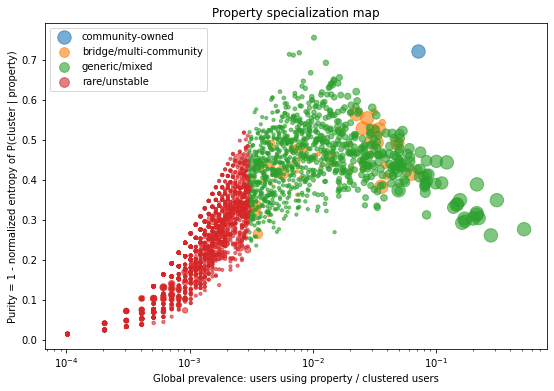

In [53]:
# Community-owned properties from existing notebook objects:
# expects: agg (columns: user, property, count), user_index, labels
# optional: prop_index; noise label (-1) is excluded by default

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 0) Build user -> cluster map
# ----------------------------
user_cluster = pd.DataFrame({
    "user": pd.Index(user_index).astype(str),
    "cluster": labels
})

EXCLUDE_NOISE = True
if EXCLUDE_NOISE:
    user_cluster = user_cluster[user_cluster["cluster"] != -1].copy()

# ----------------------------
# 1) User-incidence table
#    n_pc = # users in cluster c who used property p at least once
# ----------------------------
user_prop = agg[["user", "property"]].drop_duplicates().copy()
user_prop["user"] = user_prop["user"].astype(str)

upc = user_prop.merge(user_cluster, on="user", how="inner")

n_pc = (
    upc.groupby(["property", "cluster"])["user"]
       .nunique()
       .rename("n_pc")
       .reset_index()
)

n_p = (
    upc.groupby("property")["user"]
       .nunique()
       .rename("n_p")
       .reset_index()
)

n_c = (
    user_cluster.groupby("cluster")["user"]
       .nunique()
       .rename("n_c")
       .reset_index()
)

N = int(n_c["n_c"].sum())
clusters = np.sort(n_c["cluster"].unique())
K = len(clusters)

# complete property x cluster grid so entropy is correct
grid = pd.MultiIndex.from_product(
    [n_p["property"].unique(), clusters], names=["property", "cluster"]
).to_frame(index=False)

pc = (
    grid.merge(n_pc, on=["property", "cluster"], how="left")
        .merge(n_p, on="property", how="left")
        .merge(n_c, on="cluster", how="left")
)
pc["n_pc"] = pc["n_pc"].fillna(0)

# ----------------------------
# 2) Smoothed conditional probabilities
# ----------------------------
alpha = 0.5  # smoothing for stability

# share = P(cluster | property)
pc["share_pc"] = (pc["n_pc"] + alpha) / (pc["n_p"] + alpha * K)

# coverage = P(property | cluster)
pc["coverage_pc"] = (pc["n_pc"] + alpha) / (pc["n_c"] + 2 * alpha)

# baseline cluster size
pc["cluster_base"] = pc["n_c"] / N

# enrichment of cluster among property users relative to cluster size
pc["enrichment_pc"] = pc["share_pc"] / pc["cluster_base"]
pc["log_enrichment_pc"] = np.log2(pc["enrichment_pc"])

# ----------------------------
# 3) Property-level concentration / ownership
# ----------------------------
def normalized_entropy(x):
    x = np.asarray(x, dtype=float)
    x = x / x.sum()
    h = -(x * np.log(x)).sum()
    return h / np.log(len(x)) if len(x) > 1 else 0.0

prop_entropy = (
    pc.groupby("property")["share_pc"]
      .apply(normalized_entropy)
      .rename("entropy_norm")
      .reset_index()
)
prop_entropy["purity"] = 1 - prop_entropy["entropy_norm"]

owner = (
    pc.sort_values(["property", "share_pc", "coverage_pc"], ascending=[True, False, False])
      .groupby("property", as_index=False)
      .first()[["property", "cluster", "n_pc", "n_p", "n_c", "share_pc", "coverage_pc", "enrichment_pc", "log_enrichment_pc"]]
      .rename(columns={
          "cluster": "owner_cluster",
          "n_pc": "owner_users",
          "share_pc": "owner_share",
          "coverage_pc": "owner_coverage",
          "enrichment_pc": "owner_enrichment",
          "log_enrichment_pc": "owner_log2_enrichment"
      })
)

# second-best cluster share to detect "bridge" properties
share_rank = (
    pc[["property", "cluster", "share_pc"]]
      .sort_values(["property", "share_pc"], ascending=[True, False])
)
share_rank["rank"] = share_rank.groupby("property").cumcount() + 1
second_share = (
    share_rank[share_rank["rank"] == 2][["property", "share_pc"]]
      .rename(columns={"share_pc": "second_share"})
)

property_scores = (
    owner.merge(prop_entropy, on="property", how="left")
         .merge(second_share, on="property", how="left")
)
property_scores["second_share"] = property_scores["second_share"].fillna(0)

# support shrinkage so tiny properties do not dominate
lam = 25.0
property_scores["support_weight"] = property_scores["n_p"] / (property_scores["n_p"] + lam)

# composite ranking score (for ranking only, not the hard definition)
property_scores["owned_score"] = (
    property_scores["purity"]
    * property_scores["owner_coverage"]
    * np.log1p(property_scores["owner_enrichment"])
    * property_scores["support_weight"]
)

# ----------------------------
# 4) Classification rule
# ----------------------------
MIN_SUPPORT = 30
MIN_OWNER_SHARE = 0.60
MIN_OWNER_COVERAGE = 0.05
MIN_OWNER_ENRICHMENT = 2.0
BRIDGE_SECOND_SHARE = 0.25

def classify(row):
    if row["n_p"] < MIN_SUPPORT:
        return "rare/unstable"
    if (
        row["owner_share"] >= MIN_OWNER_SHARE
        and row["owner_coverage"] >= MIN_OWNER_COVERAGE
        and row["owner_enrichment"] >= MIN_OWNER_ENRICHMENT
    ):
        return "community-owned"
    if row["second_share"] >= BRIDGE_SECOND_SHARE and row["purity"] >= 0.20:
        return "bridge/multi-community"
    return "generic/mixed"

property_scores["class"] = property_scores.apply(classify, axis=1)

# ----------------------------
# 5) Compact outputs to inspect
# ----------------------------
cols = [
    "property", "owner_cluster", "class", "n_p",
    "owner_users", "owner_share", "second_share",
    "owner_coverage", "owner_enrichment", "purity", "owned_score"
]

print("\nClass counts:")
print(property_scores["class"].value_counts(dropna=False).to_string())

print("\nTop community-owned properties:")
display(
    property_scores[property_scores["class"].eq("community-owned")]
    .sort_values("owned_score", ascending=False)[cols]
    .head(30)
    .style.format({
        "owner_share": "{:.3f}",
        "second_share": "{:.3f}",
        "owner_coverage": "{:.3f}",
        "owner_enrichment": "{:.2f}",
        "purity": "{:.3f}",
        "owned_score": "{:.4f}",
    })
)

print("\nMost generic / mixed properties:")
display(
    property_scores[property_scores["class"].eq("generic/mixed")]
    .sort_values(["purity", "n_p"], ascending=[True, False])[cols]
    .head(20)
    .style.format({
        "owner_share": "{:.3f}",
        "second_share": "{:.3f}",
        "owner_coverage": "{:.3f}",
        "owner_enrichment": "{:.2f}",
        "purity": "{:.3f}",
        "owned_score": "{:.4f}",
    })
)

print("\nBridge / multi-community properties:")
display(
    property_scores[property_scores["class"].eq("bridge/multi-community")]
    .sort_values("owned_score", ascending=False)[cols]
    .head(20)
    .style.format({
        "owner_share": "{:.3f}",
        "second_share": "{:.3f}",
        "owner_coverage": "{:.3f}",
        "owner_enrichment": "{:.2f}",
        "purity": "{:.3f}",
        "owned_score": "{:.4f}",
    })
)

# Top properties per owner cluster
top_by_cluster = (
    property_scores[property_scores["class"].eq("community-owned")]
    .sort_values(["owner_cluster", "owned_score"], ascending=[True, False])
    .groupby("owner_cluster")
    .head(10)[cols]
)

print("\nTop 10 community-owned properties per cluster:")
display(
    top_by_cluster.style.format({
        "owner_share": "{:.3f}",
        "second_share": "{:.3f}",
        "owner_coverage": "{:.3f}",
        "owner_enrichment": "{:.2f}",
        "purity": "{:.3f}",
        "owned_score": "{:.4f}",
    })
)

# ----------------------------
# 6) Diagnostic plot
# ----------------------------
plot_df = property_scores.copy()
plot_df["global_prevalence"] = plot_df["n_p"] / N

fig, ax = plt.subplots(figsize=(9, 6))
for klass in ["community-owned", "bridge/multi-community", "generic/mixed", "rare/unstable"]:
    sub = plot_df[plot_df["class"] == klass]
    if len(sub) == 0:
        continue
    ax.scatter(
        sub["global_prevalence"],
        sub["purity"],
        s=np.clip(sub["owner_coverage"] * 1200, 10, 180),
        alpha=0.6,
        label=klass
    )

ax.set_xscale("log")
ax.set_xlabel("Global prevalence: users using property / clustered users")
ax.set_ylabel("Purity = 1 - normalized entropy of P(cluster | property)")
ax.set_title("Property specialization map")
ax.legend()
plt.show()

# ----------------------------
# 7) Drill-down helper
# ----------------------------
def inspect_property(prop_id):
    out = pc.loc[pc["property"] == prop_id, ["property", "cluster", "n_pc", "n_p", "n_c", "share_pc", "coverage_pc", "enrichment_pc"]].copy()
    out = out.sort_values("share_pc", ascending=False)
    meta = property_scores.loc[property_scores["property"] == prop_id, cols]
    print("\nSummary:")
    display(meta.style.format({
        "owner_share": "{:.3f}",
        "second_share": "{:.3f}",
        "owner_coverage": "{:.3f}",
        "owner_enrichment": "{:.2f}",
        "purity": "{:.3f}",
        "owned_score": "{:.4f}",
    }))
    print("\nCluster breakdown:")
    display(out.head(15).style.format({
        "share_pc": "{:.3f}",
        "coverage_pc": "{:.3f}",
        "enrichment_pc": "{:.2f}",
    }))

# Example:
# inspect_property("P348")
# inspect_property("P18")
# inspect_property("P21")

In [54]:
inspect_property("P21")


Summary:


,property,owner_cluster,class,n_p,owner_users,owner_share,second_share,owner_coverage,owner_enrichment,purity,owned_score
2348,P21,22,generic/mixed,2089,807.000000,0.384,0.162,0.175,0.81,0.313,0.0322



Cluster breakdown:


,property,cluster,n_pc,n_p,n_c,share_pc,coverage_pc,enrichment_pc
56374,P21,22,807.000000,2089,4616,0.384,0.175,0.81
56358,P21,6,340.000000,2089,340,0.162,0.999,4.66
56357,P21,5,199.000000,2089,199,0.095,0.998,4.67
56356,P21,4,161.000000,2089,161,0.077,0.997,4.67
56375,P21,23,79.000000,2089,660,0.038,0.120,0.56
56354,P21,2,75.000000,2089,144,0.036,0.521,2.44
56362,P21,10,68.000000,2089,552,0.033,0.124,0.58
56373,P21,21,54.000000,2089,164,0.026,0.330,1.55
56363,P21,11,49.000000,2089,223,0.024,0.221,1.03
56366,P21,14,45.000000,2089,255,0.022,0.178,0.83


Cluster sizes:


,n_users
0,104
1,165
2,144
3,179
4,161
5,199
6,340
7,117
8,132
9,144



Quantiles over properties with n_p >= 30:


,n_p,owner_share,second_share,owner_coverage,owner_enrichment,purity,owned_score
0.25,42.00,0.516598,0.054588,0.006823,1.111021,0.394428,0.001408
0.50,67.00,0.588889,0.072475,0.010396,1.256706,0.444627,0.003014
0.75,140.25,0.653381,0.107143,0.021118,1.392556,0.500208,0.007300
0.90,309.10,0.700000,0.189000,0.043426,1.496897,0.549822,0.016501
0.95,489.05,0.730869,0.250084,0.070728,1.589363,0.581891,0.025069
0.99,1544.60,0.777486,0.342406,0.259494,14.228238,0.642570,0.190089



Soft class counts:
rare/unstable             7296
generic/mixed             1024
bridge/multi-community      51
community-owned-soft         5

Top soft community-owned properties:


,property,owner_cluster,class_soft,n_p,owner_users,owner_share,second_share,owner_coverage,owner_enrichment,purity,owned_score
3525,P348,10,community-owned-soft,692,552.000000,0.785,0.136,0.999,13.91,0.723,1.8841
1922,P161,11,community-owned-soft,475,223.000000,0.459,0.328,0.998,20.13,0.491,1.4209
1670,P1324,10,community-owned-soft,270,143.000000,0.509,0.328,0.259,9.02,0.554,0.3032
2928,P277,10,community-owned-soft,221,117.000000,0.504,0.350,0.212,8.94,0.565,0.2475
1776,P1414,10,community-owned-soft,45,28.000000,0.500,0.307,0.052,8.86,0.489,0.0371



Borderline properties (high enrichment, moderate concentration):


,property,owner_cluster,class_soft,n_p,owner_share,second_share,owner_coverage,owner_enrichment,purity,owned_score
2928,P277,10,community-owned-soft,221,0.504,0.350,0.212,8.94,0.565,0.2475
1670,P1324,10,community-owned-soft,270,0.509,0.328,0.259,9.02,0.554,0.3032
4259,P433,3,bridge/multi-community,249,0.435,0.324,0.631,23.76,0.529,0.9726
2910,P275,10,bridge/multi-community,336,0.412,0.401,0.259,7.31,0.526,0.2691
4615,P478,3,bridge/multi-community,302,0.419,0.349,0.731,22.89,0.522,1.1186
1922,P161,11,community-owned-soft,475,0.459,0.328,0.998,20.13,0.491,1.4209
1776,P1414,10,community-owned-soft,45,0.500,0.307,0.052,8.86,0.489,0.0371
1764,P1401,10,bridge/multi-community,81,0.435,0.349,0.073,7.72,0.478,0.0580
2326,P2078,10,bridge/multi-community,68,0.444,0.344,0.064,7.86,0.476,0.0488
5386,P5775,23,bridge/multi-community,135,0.425,0.344,0.095,6.30,0.459,0.0728


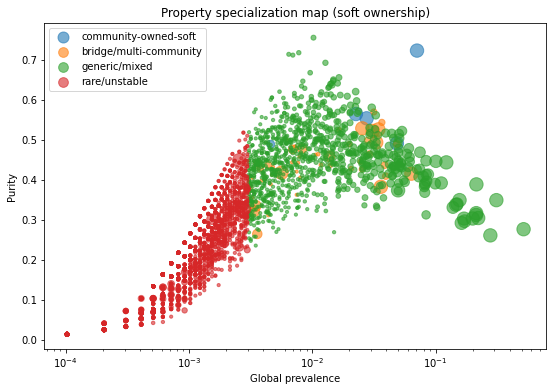

In [55]:
# Recalibrate thresholds from observed distributions, then compare strict vs soft ownership

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Quick diagnostics
print("Cluster sizes:")
display(
    user_cluster["cluster"].value_counts().sort_index().rename("n_users").to_frame()
)

diag_cols = ["n_p", "owner_share", "second_share", "owner_coverage", "owner_enrichment", "purity", "owned_score"]
print("\nQuantiles over properties with n_p >= 30:")
display(
    property_scores.loc[property_scores["n_p"] >= 30, diag_cols]
    .quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
)

# 2) Softer classification
SOFT_MIN_SUPPORT = 30
SOFT_MIN_OWNER_SHARE = 0.45      # was 0.60
SOFT_MIN_OWNER_ENRICHMENT = 3.0  # keep specificity
SOFT_MIN_PURITY = 0.45           # require concentration
SOFT_MIN_OWNER_COVERAGE = 0.02   # was 0.05; less harsh for larger clusters
SOFT_MAX_SECOND_SHARE = 0.35     # avoid clear 2-cluster bridges

def classify_soft(row):
    if row["n_p"] < SOFT_MIN_SUPPORT:
        return "rare/unstable"
    if (
        row["owner_share"] >= SOFT_MIN_OWNER_SHARE
        and row["owner_enrichment"] >= SOFT_MIN_OWNER_ENRICHMENT
        and row["purity"] >= SOFT_MIN_PURITY
        and row["owner_coverage"] >= SOFT_MIN_OWNER_COVERAGE
        and row["second_share"] <= SOFT_MAX_SECOND_SHARE
    ):
        return "community-owned-soft"
    if row["second_share"] >= 0.25 and row["purity"] >= 0.20:
        return "bridge/multi-community"
    return "generic/mixed"

property_scores["class_soft"] = property_scores.apply(classify_soft, axis=1)

print("\nSoft class counts:")
print(property_scores["class_soft"].value_counts().to_string())

cols = [
    "property", "owner_cluster", "class_soft", "n_p", "owner_users",
    "owner_share", "second_share", "owner_coverage",
    "owner_enrichment", "purity", "owned_score"
]

print("\nTop soft community-owned properties:")
display(
    property_scores[property_scores["class_soft"].eq("community-owned-soft")]
    .sort_values(["owned_score", "n_p"], ascending=False)[cols]
    .head(40)
    .style.format({
        "owner_share": "{:.3f}",
        "second_share": "{:.3f}",
        "owner_coverage": "{:.3f}",
        "owner_enrichment": "{:.2f}",
        "purity": "{:.3f}",
        "owned_score": "{:.4f}",
    })
)

# 3) Show borderline cases near the ownership boundary
print("\nBorderline properties (high enrichment, moderate concentration):")
border = property_scores[
    (property_scores["n_p"] >= 30) &
    (property_scores["owner_enrichment"] >= 3) &
    (property_scores["owner_share"].between(0.40, 0.60))
].sort_values(["purity", "owned_score"], ascending=False)

display(
    border[[
        "property", "owner_cluster", "class_soft", "n_p",
        "owner_share", "second_share", "owner_coverage",
        "owner_enrichment", "purity", "owned_score"
    ]].head(30).style.format({
        "owner_share": "{:.3f}",
        "second_share": "{:.3f}",
        "owner_coverage": "{:.3f}",
        "owner_enrichment": "{:.2f}",
        "purity": "{:.3f}",
        "owned_score": "{:.4f}",
    })
)

# 4) Plot soft classes
plot_df = property_scores.copy()
plot_df["global_prevalence"] = plot_df["n_p"] / N

fig, ax = plt.subplots(figsize=(9, 6))
for klass in ["community-owned-soft", "bridge/multi-community", "generic/mixed", "rare/unstable"]:
    sub = plot_df[plot_df["class_soft"].eq(klass)]
    if len(sub) == 0:
        continue
    ax.scatter(
        sub["global_prevalence"],
        sub["purity"],
        s=np.clip(sub["owner_coverage"] * 1200, 10, 180),
        alpha=0.6,
        label=klass
    )

ax.set_xscale("log")
ax.set_xlabel("Global prevalence")
ax.set_ylabel("Purity")
ax.set_title("Property specialization map (soft ownership)")
ax.legend()
plt.show()

## rank user–property domination pairs: cases where one user is unusually dominant on one property relative to everyone else who edits that property.


Top user-property domination pairs:


,user,property,count,prop_total_edits,user_total_edits,property_edit_share,user_focus_share,second_count,second_property_share,share_gap,property_hhi,property_purity_users,domination_score
3396,Harej,P2860,36446372,39726385,40773504,0.917,0.894,1834683,0.046,0.871,0.844,0.934,21.661
431,Thomasstjerne,P10585,2057355,2114282,2058765,0.973,0.999,32089,0.015,0.958,0.947,0.973,20.829
873,Reptilien.19831209BE1,P11249,163125,164684,172105,0.991,0.948,425,0.003,0.988,0.981,0.984,17.180
7915,Vladimir Alexiev,P7859,1645971,1847110,1799032,0.891,0.915,60157,0.033,0.859,0.795,0.906,17.149
9309,EOLTraits,P9566,684907,685970,1014776,0.998,0.675,799,0.001,0.997,0.997,0.996,16.493
297,Steam Flow,P10387,88120,88767,91461,0.993,0.963,192,0.002,0.991,0.985,0.984,16.471
8386,Mkbergman,P8408,55965,57266,56020,0.977,0.999,73,0.001,0.976,0.955,0.962,15.616
3473,Lesko987a,P2949,364971,418385,365774,0.872,0.998,8095,0.019,0.853,0.762,0.878,15.377
5588,Denengelse,P5207,198860,203992,255970,0.975,0.777,2054,0.010,0.965,0.951,0.957,15.272
1611,Vicarage,P12485,456745,459004,767182,0.995,0.595,1902,0.004,0.991,0.990,0.991,14.918



Top user-focused pairs (user spent large fraction of own edits on the property):


,user,property,count,prop_total_edits,user_total_edits,property_edit_share,user_focus_share,second_count,second_property_share,share_gap,property_hhi,property_purity_users,domination_score
1896,KISTI Data,P13092,31908,32517,31910,0.981,1.000,506,0.016,0.966,0.963,0.964,14.900
9141,Tpd13,P9338,12844,22045,12846,0.583,1.000,7844,0.356,0.227,0.468,0.761,6.951
8193,Minak,P8172,38469,54071,38478,0.711,1.000,4808,0.089,0.623,0.522,0.766,9.510
9640,VerifyToday,P9964,58753,260599,58769,0.225,1.000,55161,0.212,0.014,0.139,0.546,2.590
3397,HeijnaA,P2861,2482,4554,2483,0.545,1.000,952,0.209,0.336,0.359,0.648,4.892
1923,Jousep Bernhard,P13183,27146,29750,27163,0.912,0.999,2361,0.079,0.833,0.839,0.883,12.881
7025,Elhuyar Fundazioa,P6838,3011,3027,3013,0.995,0.999,9,0.003,0.992,0.989,0.978,11.773
431,Thomasstjerne,P10585,2057355,2114282,2058765,0.973,0.999,32089,0.015,0.958,0.947,0.973,20.829
2999,Thisismattmiller,P244,426138,1028361,426447,0.414,0.999,65140,0.063,0.351,0.181,0.569,5.742
4451,Ericmclachlan,P3984,4294,17053,4298,0.252,0.999,2401,0.141,0.111,0.104,0.498,2.100



Top property-owner pairs (largest share of a property captured by one user):


,user,property,count,prop_total_edits,user_total_edits,property_edit_share,user_focus_share,second_count,second_property_share,share_gap,property_hhi,property_purity_users,domination_score
1938,Ghuron,P13228,3863490,3863503,111184442,1.000,0.035,6,0.000,1.000,1.000,1.000,4.241
2786,Ghuron,P2215,7014782,7015030,111184442,1.000,0.063,60,0.000,1.000,1.000,1.000,5.938
6506,Ghuron,P6259,6940774,6941428,111184442,1.000,0.062,161,0.000,1.000,1.000,1.000,5.902
9376,Liber008,P9645,47851,47857,576405,1.000,0.083,2,0.000,1.000,1.000,0.999,4.654
6505,Ghuron,P6258,7058375,7059386,111184442,1.000,0.063,550,0.000,1.000,1.000,1.000,5.958
2787,Ghuron,P2216,3239629,3240098,111184442,1.000,0.029,186,0.000,1.000,1.000,1.000,3.837
6504,Ghuron,P6257,7105471,7106537,111184442,1.000,0.064,545,0.000,1.000,1.000,1.000,5.980
756,Bamyers99,P11089,1014164,1014370,2334598,1.000,0.434,50,0.000,1.000,1.000,0.999,13.664
1763,Sebotic,P128,315322,315406,512358,1.000,0.615,42,0.000,1.000,0.999,0.999,14.885
1838,Liber008,P12949,51136,51151,576405,1.000,0.089,9,0.000,1.000,0.999,0.998,4.838


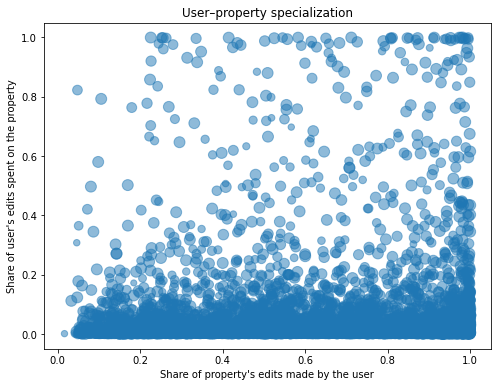

'\ncites work (P2860)\nCatalogue of Life ID (P10585)\nKBR person ID (P11249)\nWorldCat Entities ID (P7859) - deleted\ndiel cycle (P9566) -- pattern of diel activity in animals, such as "nocturnal" (Q101029366), "diurnal" (Q4284186)\nDatabazeknih.cz author ID (P10387)\northolog (P684)  -- orthologous gene in another species\nKBpedia ID (P8408)\nWikiTree person ID (P2949)\nBAG public space ID (P5207)\nBritish Listed Buildings ID (P12485)\nKISTI ID (P13092)\nregulates (molecular biology) (P128)\n'

In [56]:
# User-property domination analysis
# expects: agg with columns [user, property, count]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = agg[["user", "property", "count"]].copy()
df["user"] = df["user"].astype(str)
df["property"] = df["property"].astype(str)

# -------------------------------------------------
# 1) Property totals and user shares within property
# -------------------------------------------------
prop_totals = (
    df.groupby("property")["count"]
      .sum()
      .rename("prop_total_edits")
      .reset_index()
)

user_totals = (
    df.groupby("user")["count"]
      .sum()
      .rename("user_total_edits")
      .reset_index()
)

up = (
    df.merge(prop_totals, on="property", how="left")
      .merge(user_totals, on="user", how="left")
)

up["property_edit_share"] = up["count"] / up["prop_total_edits"]     # share of all edits to property p made by user u
up["user_focus_share"] = up["count"] / up["user_total_edits"]        # share of user's own edits spent on property p

# -------------------------------------------------
# 2) Rank within each property
# -------------------------------------------------
up = up.sort_values(["property", "count"], ascending=[True, False]).copy()
up["rank_in_property"] = up.groupby("property").cumcount() + 1

top1 = up[up["rank_in_property"] == 1].copy()
top2 = (
    up[up["rank_in_property"] == 2][["property", "count", "user", "property_edit_share"]]
      .rename(columns={
          "count": "second_count",
          "user": "second_user",
          "property_edit_share": "second_property_share"
      })
)

leaders = top1.merge(top2, on="property", how="left")
leaders["second_count"] = leaders["second_count"].fillna(0)
leaders["second_property_share"] = leaders["second_property_share"].fillna(0)

# dominance gaps
leaders["count_ratio_vs_second"] = leaders["count"] / leaders["second_count"].replace(0, np.nan)
leaders["share_gap"] = leaders["property_edit_share"] - leaders["second_property_share"]
leaders["solo_flag"] = leaders["second_count"].eq(0)

# -------------------------------------------------
# 3) Concentration of each property across users
# -------------------------------------------------
tmp = up[["property", "user", "count"]].copy()
tmp["p_user_given_property"] = tmp["count"] / tmp.groupby("property")["count"].transform("sum")

def hhi(x):
    x = np.asarray(x, dtype=float)
    return np.sum(x**2)

def entropy_norm(x):
    x = np.asarray(x, dtype=float)
    x = x[x > 0]
    if len(x) <= 1:
        return 0.0
    h = -(x * np.log(x)).sum()
    return h / np.log(len(x))

prop_conc = (
    tmp.groupby("property")["p_user_given_property"]
       .agg(property_hhi=hhi, property_entropy_norm=entropy_norm)
       .reset_index()
)
prop_conc["property_purity_users"] = 1 - prop_conc["property_entropy_norm"]

# -------------------------------------------------
# 4) User-level specialization strength for the pair
# -------------------------------------------------
# TF-like dominance from user side + ownership from property side
leaders = leaders.merge(prop_conc, on="property", how="left")

# support/stability filters
leaders["log_count"] = np.log10(leaders["count"] + 1)
leaders["log_prop_total"] = np.log10(leaders["prop_total_edits"] + 1)

# composite score:
# high if user owns much of the property, focuses strongly on it, has real volume,
# and the property itself is concentrated among few users
leaders["domination_score"] = (
    leaders["property_edit_share"]
    * np.sqrt(leaders["user_focus_share"])
    * np.log1p(leaders["count"])
    * (0.5 + leaders["property_purity_users"])
)

# -------------------------------------------------
# 5) Useful filtered views
# -------------------------------------------------
MIN_USER_PROPERTY_EDITS = 20
MIN_PROPERTY_TOTAL_EDITS = 50

cand = leaders[
    (leaders["count"] >= MIN_USER_PROPERTY_EDITS) &
    (leaders["prop_total_edits"] >= MIN_PROPERTY_TOTAL_EDITS)
].copy()

# A) strongest "one user dominates one property"
top_domination = cand.sort_values(
    ["domination_score", "property_edit_share", "count"],
    ascending=False
)

# B) strongest "user is highly focused on one property"
top_focus = cand.sort_values(
    ["user_focus_share", "count", "property_edit_share"],
    ascending=False
)

# C) strongest "winner-take-most" properties
top_owned_properties = cand.sort_values(
    ["property_edit_share", "share_gap", "count"],
    ascending=False
)

cols = [
    "user", "property", "count", "prop_total_edits", "user_total_edits",
    "property_edit_share", "user_focus_share", "second_count",
    "second_property_share", "share_gap", "property_hhi",
    "property_purity_users", "domination_score"
]

print("\nTop user-property domination pairs:")
display(
    top_domination[cols].head(40).style.format({
        "property_edit_share": "{:.3f}",
        "user_focus_share": "{:.3f}",
        "second_property_share": "{:.3f}",
        "share_gap": "{:.3f}",
        "property_hhi": "{:.3f}",
        "property_purity_users": "{:.3f}",
        "domination_score": "{:.3f}",
    })
)

print("\nTop user-focused pairs (user spent large fraction of own edits on the property):")
display(
    top_focus[cols].head(40).style.format({
        "property_edit_share": "{:.3f}",
        "user_focus_share": "{:.3f}",
        "second_property_share": "{:.3f}",
        "share_gap": "{:.3f}",
        "property_hhi": "{:.3f}",
        "property_purity_users": "{:.3f}",
        "domination_score": "{:.3f}",
    })
)

print("\nTop property-owner pairs (largest share of a property captured by one user):")
display(
    top_owned_properties[cols].head(40).style.format({
        "property_edit_share": "{:.3f}",
        "user_focus_share": "{:.3f}",
        "second_property_share": "{:.3f}",
        "share_gap": "{:.3f}",
        "property_hhi": "{:.3f}",
        "property_purity_users": "{:.3f}",
        "domination_score": "{:.3f}",
    })
)

# -------------------------------------------------
# 6) Plot: ownership vs user focus
# -------------------------------------------------
plot_df = cand.copy()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    plot_df["property_edit_share"],
    plot_df["user_focus_share"],
    s=np.clip(np.log1p(plot_df["count"]) * 12, 8, 120),
    alpha=0.5
)
ax.set_xlabel("Share of property's edits made by the user")
ax.set_ylabel("Share of user's edits spent on the property")
ax.set_title("User–property specialization")
plt.show()

# -------------------------------------------------
# 7) Drill-down helpers
# -------------------------------------------------
def inspect_property_users(prop_id, topn=15):
    z = up[up["property"] == str(prop_id)].sort_values("count", ascending=False).copy()
    display(
        z[["property", "user", "count", "property_edit_share", "user_focus_share"]]
        .head(topn)
        .style.format({
            "property_edit_share": "{:.3f}",
            "user_focus_share": "{:.3f}",
        })
    )

def inspect_user_properties(user_id, topn=15):
    z = up[up["user"] == str(user_id)].sort_values("count", ascending=False).copy()
    display(
        z[["user", "property", "count", "property_edit_share", "user_focus_share"]]
        .head(topn)
        .style.format({
            "property_edit_share": "{:.3f}",
            "user_focus_share": "{:.3f}",
        })
    )

# Example usage after inspecting tables:
# inspect_property_users("P214")
# inspect_user_properties("SomeUserName")

'''
cites work (P2860)
Catalogue of Life ID (P10585)
KBR person ID (P11249)
WorldCat Entities ID (P7859) - deleted
diel cycle (P9566) -- pattern of diel activity in animals, such as "nocturnal" (Q101029366), "diurnal" (Q4284186)
Databazeknih.cz author ID (P10387)
ortholog (P684)  -- orthologous gene in another species
KBpedia ID (P8408)
WikiTree person ID (P2949)
BAG public space ID (P5207)
British Listed Buildings ID (P12485)
KISTI ID (P13092)
regulates (molecular biology) (P128)
'''


Users owning the most properties:


,user,n_owned_properties,total_owned_edits,mean_property_share,median_property_share,mean_user_focus,max_user_focus,total_user_edits,owned_edit_fraction,top_owned_properties
151,Ikan,8,14778,0.845,0.846,0.114,0.117,16172,0.914,"P11290, P11291, P11289, P11288, P11287"
119,Ghuron,8,78916128,0.996,1.000,0.089,0.217,111184442,0.710,"P528, P1215, P3083, P6257, P6258"
304,RPI2026F1,6,27348,0.927,0.939,0.065,0.068,69688,0.392,"P12477, P11495, P12427, P11349, P11149"
201,LesserJerome,5,65896,0.998,0.999,0.108,0.115,122409,0.538,"P6546, P6544, P6545, P6547, P6543"
364,Tibbs001,5,1530970,0.953,0.997,0.071,0.077,4288580,0.357,"P3098, P8363, P1132, P2899, P6153"
3,813gan,4,25614,0.912,0.897,0.250,0.330,25645,0.999,"P2132, P2134, P2299, P4010"
411,白布飘扬,4,222572,0.961,0.963,0.114,0.249,490174,0.454,"P5753, P5280, P5205, P5475"
30,Arch2all,3,75944,0.942,0.949,0.257,0.397,98674,0.770,"P5573, P5383, P5508"
222,Mabschaaf,3,52567,0.914,0.954,0.193,0.467,90818,0.579,"P2566, P2062, P10113"
187,Kirilloparma,3,176384,0.923,0.950,0.158,0.225,371078,0.475,"P12683, P12001, P5494"



Users whose activity is most concentrated in owned properties:


,user,n_owned_properties,total_owned_edits,mean_property_share,median_property_share,mean_user_focus,max_user_focus,total_user_edits,owned_edit_fraction,top_owned_properties
178,KISTI Data,1,31908,0.981,0.981,1.000,1.000,31910,1.000,P13092
171,Jousep Bernhard,1,27146,0.912,0.912,0.999,0.999,27163,0.999,P13183
104,Elhuyar Fundazioa,1,3011,0.995,0.995,0.999,0.999,3013,0.999,P6838
363,Thomasstjerne,1,2057355,0.973,0.973,0.999,0.999,2058765,0.999,P10585
243,Mkbergman,1,55965,0.977,0.977,0.999,0.999,56020,0.999,P8408
260,Nonodename,1,5056,0.811,0.811,0.999,0.999,5061,0.999,P3347
93,Dr vulpes,1,14090,0.952,0.952,0.999,0.999,14107,0.999,P3648
3,813gan,4,25614,0.912,0.897,0.250,0.330,25645,0.999,"P2132, P2134, P2299, P4010"
98,Dux Oppositionis,1,805,0.911,0.911,0.999,0.999,806,0.999,P11819
147,Hyarion,1,1293,0.851,0.851,0.998,0.998,1295,0.998,P11935


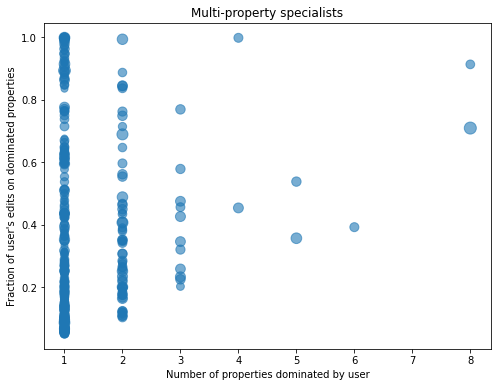

In [57]:
# Multi-property specialist users: who dominates many different properties?

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use the already computed `leaders` table from the previous cell
# columns expected there:
# user, property, count, prop_total_edits, user_total_edits,
# property_edit_share, user_focus_share, domination_score, etc.

# --------------------------
# 1) Define "owned property"
# --------------------------
OWN_MIN_USER_EDITS = 20
OWN_MIN_PROP_TOTAL = 50
OWN_MIN_PROP_SHARE = 0.75   # user made at least 75% of edits on that property
OWN_MIN_FOCUS = 0.05        # property is at least 5% of user's edits

owned_pairs = leaders[
    (leaders["count"] >= OWN_MIN_USER_EDITS) &
    (leaders["prop_total_edits"] >= OWN_MIN_PROP_TOTAL) &
    (leaders["property_edit_share"] >= OWN_MIN_PROP_SHARE) &
    (leaders["user_focus_share"] >= OWN_MIN_FOCUS)
].copy()

# --------------------------
# 2) Aggregate by user
# --------------------------
user_owned = (
    owned_pairs.groupby("user")
    .agg(
        n_owned_properties=("property", "nunique"),
        total_owned_edits=("count", "sum"),
        mean_property_share=("property_edit_share", "mean"),
        median_property_share=("property_edit_share", "median"),
        mean_user_focus=("user_focus_share", "mean"),
        max_user_focus=("user_focus_share", "max"),
        total_user_edits=("user_total_edits", "max"),
    )
    .reset_index()
)

# how concentrated is a user's owned portfolio?
user_owned["owned_edit_fraction"] = user_owned["total_owned_edits"] / user_owned["total_user_edits"]

# --------------------------
# 3) Merge top properties per user
# --------------------------
top_props_per_user = (
    owned_pairs.sort_values(["user", "count"], ascending=[True, False])
    .groupby("user")
    .head(5)
    .groupby("user")["property"]
    .apply(lambda s: ", ".join(map(str, s.tolist())))
    .rename("top_owned_properties")
    .reset_index()
)

user_owned = user_owned.merge(top_props_per_user, on="user", how="left")

# --------------------------
# 4) Rankings
# --------------------------
print("\nUsers owning the most properties:")
display(
    user_owned.sort_values(
        ["n_owned_properties", "owned_edit_fraction", "total_owned_edits"],
        ascending=False
    ).head(40).style.format({
        "mean_property_share": "{:.3f}",
        "median_property_share": "{:.3f}",
        "mean_user_focus": "{:.3f}",
        "max_user_focus": "{:.3f}",
        "owned_edit_fraction": "{:.3f}",
    })
)

print("\nUsers whose activity is most concentrated in owned properties:")
display(
    user_owned.sort_values(
        ["owned_edit_fraction", "n_owned_properties", "total_owned_edits"],
        ascending=False
    ).head(40).style.format({
        "mean_property_share": "{:.3f}",
        "median_property_share": "{:.3f}",
        "mean_user_focus": "{:.3f}",
        "max_user_focus": "{:.3f}",
        "owned_edit_fraction": "{:.3f}",
    })
)

# --------------------------
# 5) Plot
# --------------------------
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    user_owned["n_owned_properties"],
    user_owned["owned_edit_fraction"],
    s=np.clip(np.log1p(user_owned["total_owned_edits"]) * 8, 10, 180),
    alpha=0.6
)
ax.set_xlabel("Number of properties dominated by user")
ax.set_ylabel("Fraction of user's edits on dominated properties")
ax.set_title("Multi-property specialists")
plt.show()

# --------------------------
# 6) Inspect one user
# --------------------------
def inspect_owner_user(user_id, topn=20):
    z = owned_pairs[owned_pairs["user"] == str(user_id)].sort_values("count", ascending=False).copy()
    display(
        z[[
            "user", "property", "count", "prop_total_edits",
            "property_edit_share", "user_focus_share", "domination_score"
        ]].head(topn).style.format({
            "property_edit_share": "{:.3f}",
            "user_focus_share": "{:.3f}",
            "domination_score": "{:.3f}",
        })
    )

# Example:
# inspect_owner_user("Ghuron")

Baseline thresholds:
{'MIN_USER_PROPERTY_EDITS': 20, 'MIN_PROPERTY_TOTAL_EDITS': 50, 'MIN_PROPERTY_SHARE': 0.75, 'MIN_USER_FOCUS': 0.05}

Baseline outcome:
{'n_owned_pairs': 528, 'n_editors_with_owned': 412, 'n_property_specialists': 333, 'n_portfolio_specialists': 79}

Sensitivity summary (first 20 rows):


,min_user_property_edits,min_property_total_edits,min_property_share,min_user_focus,n_owned_pairs,n_editors_with_owned,n_property_specialists,n_portfolio_specialists,median_owned_edit_fraction_property,median_owned_edit_fraction_portfolio,median_mean_property_share_property,median_mean_property_share_portfolio,jaccard_property_specialists_vs_baseline,jaccard_portfolio_specialists_vs_baseline,portfolio_stronger_by_fraction
0,10,25,0.600000,0.020000,1174,735,519,216,0.120,0.225,0.850,0.861,0.437,0.366,True
1,10,25,0.600000,0.040000,829,590,453,137,0.159,0.293,0.859,0.858,0.598,0.577,True
2,10,25,0.600000,0.060000,648,508,418,90,0.194,0.348,0.863,0.859,0.633,0.625,True
3,10,25,0.600000,0.080000,534,441,371,70,0.242,0.373,0.868,0.876,0.564,0.552,True
4,10,25,0.600000,0.100000,459,393,343,50,0.273,0.437,0.872,0.869,0.529,0.418,True
5,10,25,0.650000,0.020000,1070,682,488,194,0.121,0.227,0.871,0.877,0.482,0.407,True
6,10,25,0.650000,0.040000,759,547,422,125,0.161,0.293,0.871,0.884,0.652,0.632,True
7,10,25,0.650000,0.060000,594,469,389,80,0.200,0.344,0.875,0.886,0.683,0.656,True
8,10,25,0.650000,0.080000,490,406,343,63,0.248,0.352,0.881,0.893,0.606,0.578,True
9,10,25,0.650000,0.100000,422,365,322,43,0.273,0.434,0.889,0.893,0.560,0.435,True



Number of portfolio specialists (holding count thresholds at baseline):


min_user_focus,0.02,0.04,0.06,0.08,0.10
min_property_share,,,,,
0.60,216,137,90,70,50
0.65,194,125,80,63,43
0.70,176,112,71,56,38
0.75,157,98,63,50,34
0.80,134,81,47,38,28
0.85,112,66,39,30,21
0.90,89,53,30,22,14



Jaccard overlap of portfolio specialists vs baseline:


min_user_focus,0.020000,0.040000,0.060000,0.080000,0.100000
min_property_share,,,,,
0.600000,0.366,0.577,0.625,0.552,0.418
0.650000,0.407,0.632,0.656,0.578,0.435
0.700000,0.449,0.705,0.724,0.588,0.410
0.750000,0.503,0.806,0.797,0.633,0.430
0.800000,0.449,0.684,0.595,0.481,0.354
0.850000,0.425,0.593,0.494,0.380,0.266
0.900000,0.377,0.467,0.380,0.278,0.177


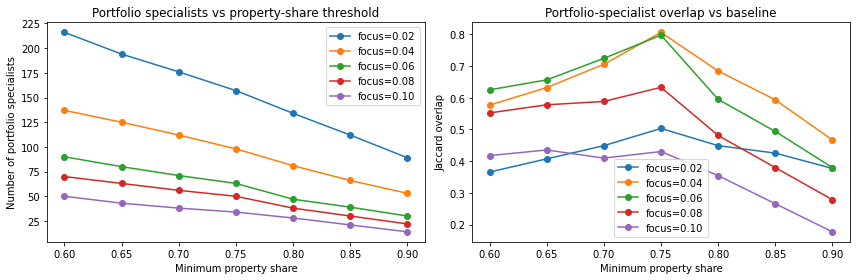


Saved: h1_threshold_sensitivity_summary.csv


In [58]:
# ---------------------------------------------
# H1 threshold sensitivity analysis
# Runs after `leaders` has been computed
# ---------------------------------------------

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- sanity check ---
required_cols = {
    "user", "property", "count", "prop_total_edits",
    "property_edit_share", "user_focus_share", "user_total_edits"
}
missing = required_cols - set(leaders.columns)
if missing:
    raise ValueError(f"`leaders` is missing required columns: {missing}")

# --------------------------------------------------
# 1) Baseline thresholds from the notebook
# --------------------------------------------------
BASE_MIN_USER_PROPERTY_EDITS = globals().get("OWN_MIN_USER_EDITS", 20)
BASE_MIN_PROPERTY_TOTAL_EDITS = globals().get("OWN_MIN_PROP_TOTAL", 50)
BASE_MIN_PROPERTY_SHARE = globals().get("OWN_MIN_PROP_SHARE", 0.75)
BASE_MIN_USER_FOCUS = globals().get("OWN_MIN_FOCUS", 0.05)

print("Baseline thresholds:")
print({
    "MIN_USER_PROPERTY_EDITS": BASE_MIN_USER_PROPERTY_EDITS,
    "MIN_PROPERTY_TOTAL_EDITS": BASE_MIN_PROPERTY_TOTAL_EDITS,
    "MIN_PROPERTY_SHARE": BASE_MIN_PROPERTY_SHARE,
    "MIN_USER_FOCUS": BASE_MIN_USER_FOCUS,
})

# --------------------------------------------------
# 2) Small robustness grid around the baseline
#    Adjust these if you want a narrower/wider grid
# --------------------------------------------------
grid_user_property_edits = [10, 20, 30]
grid_property_total_edits = [25, 50, 75, 100]
grid_property_share = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
grid_user_focus = [0.02, 0.04, 0.06, 0.08, 0.10]

# --------------------------------------------------
# 3) Helper functions
# --------------------------------------------------
def jaccard(a, b):
    a = set(a)
    b = set(b)
    if not a and not b:
        return 1.0
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)

def run_owned_analysis(df, min_user_prop_edits, min_prop_total, min_prop_share, min_user_focus):
    owned_pairs = df[
        (df["count"] >= min_user_prop_edits) &
        (df["prop_total_edits"] >= min_prop_total) &
        (df["property_edit_share"] >= min_prop_share) &
        (df["user_focus_share"] >= min_user_focus)
    ].copy()

    if owned_pairs.empty:
        return {
            "owned_pairs": owned_pairs,
            "user_owned": pd.DataFrame(columns=[
                "user", "n_owned_properties", "total_owned_edits",
                "mean_property_share", "median_property_share",
                "mean_user_focus", "max_user_focus",
                "total_user_edits", "owned_edit_fraction"
            ]),
            "property_specialists": set(),
            "portfolio_specialists": set(),
        }

    user_owned = (
        owned_pairs.groupby("user")
        .agg(
            n_owned_properties=("property", "nunique"),
            total_owned_edits=("count", "sum"),
            mean_property_share=("property_edit_share", "mean"),
            median_property_share=("property_edit_share", "median"),
            mean_user_focus=("user_focus_share", "mean"),
            max_user_focus=("user_focus_share", "max"),
            total_user_edits=("user_total_edits", "max"),
        )
        .reset_index()
    )

    user_owned["owned_edit_fraction"] = (
        user_owned["total_owned_edits"] / user_owned["total_user_edits"]
    )

    property_specialists = set(
        user_owned.loc[user_owned["n_owned_properties"] == 1, "user"]
    )
    portfolio_specialists = set(
        user_owned.loc[user_owned["n_owned_properties"] >= 2, "user"]
    )

    return {
        "owned_pairs": owned_pairs,
        "user_owned": user_owned,
        "property_specialists": property_specialists,
        "portfolio_specialists": portfolio_specialists,
    }

def summarize_run(result, thresholds, baseline_sets):
    owned_pairs = result["owned_pairs"]
    user_owned = result["user_owned"]
    prop_specs = result["property_specialists"]
    port_specs = result["portfolio_specialists"]

    if user_owned.empty:
        return {
            **thresholds,
            "n_owned_pairs": 0,
            "n_editors_with_owned": 0,
            "n_property_specialists": 0,
            "n_portfolio_specialists": 0,
            "median_owned_edit_fraction_property": np.nan,
            "median_owned_edit_fraction_portfolio": np.nan,
            "median_mean_property_share_property": np.nan,
            "median_mean_property_share_portfolio": np.nan,
            "jaccard_property_specialists_vs_baseline": 0.0,
            "jaccard_portfolio_specialists_vs_baseline": 0.0,
            "portfolio_stronger_by_fraction": False,
        }

    property_df = user_owned[user_owned["n_owned_properties"] == 1]
    portfolio_df = user_owned[user_owned["n_owned_properties"] >= 2]

    med_prop_frac = (
        property_df["owned_edit_fraction"].median()
        if not property_df.empty else np.nan
    )
    med_port_frac = (
        portfolio_df["owned_edit_fraction"].median()
        if not portfolio_df.empty else np.nan
    )

    med_prop_share_property = (
        property_df["mean_property_share"].median()
        if not property_df.empty else np.nan
    )
    med_prop_share_portfolio = (
        portfolio_df["mean_property_share"].median()
        if not portfolio_df.empty else np.nan
    )

    return {
        **thresholds,
        "n_owned_pairs": len(owned_pairs),
        "n_editors_with_owned": user_owned["user"].nunique(),
        "n_property_specialists": len(prop_specs),
        "n_portfolio_specialists": len(port_specs),
        "median_owned_edit_fraction_property": med_prop_frac,
        "median_owned_edit_fraction_portfolio": med_port_frac,
        "median_mean_property_share_property": med_prop_share_property,
        "median_mean_property_share_portfolio": med_prop_share_portfolio,
        "jaccard_property_specialists_vs_baseline": jaccard(
            prop_specs, baseline_sets["property_specialists"]
        ),
        "jaccard_portfolio_specialists_vs_baseline": jaccard(
            port_specs, baseline_sets["portfolio_specialists"]
        ),
        "portfolio_stronger_by_fraction": (
            pd.notna(med_port_frac) and pd.notna(med_prop_frac) and med_port_frac > med_prop_frac
        ),
    }

# --------------------------------------------------
# 4) Compute baseline result once
# --------------------------------------------------
baseline_result = run_owned_analysis(
    leaders,
    BASE_MIN_USER_PROPERTY_EDITS,
    BASE_MIN_PROPERTY_TOTAL_EDITS,
    BASE_MIN_PROPERTY_SHARE,
    BASE_MIN_USER_FOCUS,
)

baseline_sets = {
    "property_specialists": baseline_result["property_specialists"],
    "portfolio_specialists": baseline_result["portfolio_specialists"],
}

print("\nBaseline outcome:")
print({
    "n_owned_pairs": len(baseline_result["owned_pairs"]),
    "n_editors_with_owned": len(baseline_result["property_specialists"] | baseline_result["portfolio_specialists"]),
    "n_property_specialists": len(baseline_result["property_specialists"]),
    "n_portfolio_specialists": len(baseline_result["portfolio_specialists"]),
})

# --------------------------------------------------
# 5) Run the full sensitivity grid
# --------------------------------------------------
rows = []

for min_user_prop_edits, min_prop_total, min_prop_share, min_user_focus in itertools.product(
    grid_user_property_edits,
    grid_property_total_edits,
    grid_property_share,
    grid_user_focus,
):
    result = run_owned_analysis(
        leaders,
        min_user_prop_edits,
        min_prop_total,
        min_prop_share,
        min_user_focus,
    )

    thresholds = {
        "min_user_property_edits": min_user_prop_edits,
        "min_property_total_edits": min_prop_total,
        "min_property_share": min_prop_share,
        "min_user_focus": min_user_focus,
    }

    rows.append(summarize_run(result, thresholds, baseline_sets))

sensitivity_df = pd.DataFrame(rows).sort_values([
    "min_user_property_edits",
    "min_property_total_edits",
    "min_property_share",
    "min_user_focus"
]).reset_index(drop=True)

# --------------------------------------------------
# 6) Show the full summary
# --------------------------------------------------
print("\nSensitivity summary (first 20 rows):")
display(
    sensitivity_df.head(20).style.format({
        "median_owned_edit_fraction_property": "{:.3f}",
        "median_owned_edit_fraction_portfolio": "{:.3f}",
        "median_mean_property_share_property": "{:.3f}",
        "median_mean_property_share_portfolio": "{:.3f}",
        "jaccard_property_specialists_vs_baseline": "{:.3f}",
        "jaccard_portfolio_specialists_vs_baseline": "{:.3f}",
    })
)

# --------------------------------------------------
# 7) Compact robustness view around the baseline
#    Hold the count thresholds fixed at baseline and
#    inspect the share/focus thresholds as a pivot.
# --------------------------------------------------
pivot_slice = sensitivity_df[
    (sensitivity_df["min_user_property_edits"] == BASE_MIN_USER_PROPERTY_EDITS) &
    (sensitivity_df["min_property_total_edits"] == BASE_MIN_PROPERTY_TOTAL_EDITS)
].copy()

pivot_counts = pivot_slice.pivot(
    index="min_property_share",
    columns="min_user_focus",
    values="n_portfolio_specialists"
)

pivot_overlap = pivot_slice.pivot(
    index="min_property_share",
    columns="min_user_focus",
    values="jaccard_portfolio_specialists_vs_baseline"
)

print("\nNumber of portfolio specialists (holding count thresholds at baseline):")
display(pivot_counts)

print("\nJaccard overlap of portfolio specialists vs baseline:")
display(pivot_overlap.style.format("{:.3f}"))

# --------------------------------------------------
# 8) Simple plots
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for focus in sorted(pivot_slice["min_user_focus"].unique()):
    sub = pivot_slice[pivot_slice["min_user_focus"] == focus].sort_values("min_property_share")
    axes[0].plot(
        sub["min_property_share"],
        sub["n_portfolio_specialists"],
        marker="o",
        label=f"focus={focus:.2f}"
    )

axes[0].set_title("Portfolio specialists vs property-share threshold")
axes[0].set_xlabel("Minimum property share")
axes[0].set_ylabel("Number of portfolio specialists")
axes[0].legend()

for focus in sorted(pivot_slice["min_user_focus"].unique()):
    sub = pivot_slice[pivot_slice["min_user_focus"] == focus].sort_values("min_property_share")
    axes[1].plot(
        sub["min_property_share"],
        sub["jaccard_portfolio_specialists_vs_baseline"],
        marker="o",
        label=f"focus={focus:.2f}"
    )

axes[1].set_title("Portfolio-specialist overlap vs baseline")
axes[1].set_xlabel("Minimum property share")
axes[1].set_ylabel("Jaccard overlap")
axes[1].legend()

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 9) Optional: export summary for paper appendix
# --------------------------------------------------
sensitivity_df.to_csv("h1_threshold_sensitivity_summary.csv", index=False)
print("\nSaved: h1_threshold_sensitivity_summary.csv")

Baseline thresholds:
{'MIN_USER_PROPERTY_EDITS': 20, 'MIN_PROPERTY_TOTAL_EDITS': 50, 'MIN_PROPERTY_SHARE': 0.75, 'MIN_USER_FOCUS': 0.05}

Baseline sizes:
{'property_specialists': 333, 'portfolio_specialists': 79, 'owned_properties': 528}

Persistence summary (first 20 rows):


,min_user_property_edits,min_property_total_edits,min_property_share,min_user_focus,n_property_specialists,n_portfolio_specialists,n_owned_properties,top10_overlap_property_specialists,top10_overlap_portfolio_specialists,top10_overlap_owned_properties,top20_overlap_property_specialists,top20_overlap_portfolio_specialists,top20_overlap_owned_properties,rankcorr_property_specialists_top20,rankcorr_portfolio_specialists_top20,rankcorr_owned_properties_top20
0,10,25,0.600000,0.020000,519,216,1174,0.90,0.60,0.90,0.90,0.75,0.80,1.00,0.72,1.00
1,10,25,0.600000,0.040000,453,137,829,0.90,0.50,1.00,0.90,0.70,0.85,1.00,0.73,1.00
2,10,25,0.600000,0.060000,418,90,648,0.90,0.70,0.90,0.90,0.80,0.90,1.00,0.91,1.00
3,10,25,0.600000,0.080000,371,70,534,0.90,0.70,0.40,0.90,0.75,0.70,1.00,0.96,1.00
4,10,25,0.600000,0.100000,343,50,459,0.90,0.70,0.40,0.90,0.75,0.60,1.00,0.96,1.00
5,10,25,0.650000,0.020000,488,194,1070,0.90,0.70,0.90,0.90,0.75,0.80,1.00,0.83,1.00
6,10,25,0.650000,0.040000,422,125,759,0.90,0.70,1.00,0.90,0.85,0.90,1.00,0.87,1.00
7,10,25,0.650000,0.060000,389,80,594,0.90,0.80,0.90,0.90,0.90,0.90,1.00,0.91,1.00
8,10,25,0.650000,0.080000,343,63,490,0.90,0.90,0.40,0.90,0.80,0.70,1.00,0.96,1.00
9,10,25,0.650000,0.100000,322,43,422,0.90,0.90,0.40,0.90,0.80,0.60,1.00,0.97,1.00



Most persistent top-10 property specialists across runs:


,user,top10_appearances,share_of_runs
0,Dr vulpes,315,1.000000
1,Dux Oppositionis,315,1.000000
2,Elhuyar Fundazioa,315,1.000000
3,Jousep Bernhard,315,1.000000
4,KISTI Data,315,1.000000
5,Mkbergman,315,1.000000
6,Thomasstjerne,315,1.000000
7,Hyarion,270,0.857143
8,Nonodename,225,0.714286
9,Minak,135,0.428571



Most persistent top-10 portfolio specialists across runs:


...

,property,top10_appearances,share_of_runs
0,P1215,315,1.000000
1,P2860,315,1.000000
2,P528,315,1.000000
3,P646,252,0.800000
4,P2215,189,0.600000
5,P2888,189,0.600000
6,P3083,189,0.600000
7,P6257,189,0.600000
8,P6258,189,0.600000
9,P6259,189,0.600000



Top-10 overlap of portfolio specialists vs baseline:


min_user_focus,0.020000,0.040000,0.060000,0.080000,0.100000
min_property_share,,,,,
0.600000,0.60,0.50,0.70,0.70,0.70
0.650000,0.70,0.70,0.80,0.90,0.90
0.700000,0.70,0.80,0.90,0.90,0.90
0.750000,0.70,0.90,1.00,1.00,1.00
0.800000,0.70,0.80,0.80,0.80,0.80
0.850000,0.60,0.60,0.60,0.60,0.60
0.900000,0.30,0.30,0.40,0.40,0.40



Top-10 overlap of owned properties vs baseline:


min_user_focus,0.020000,0.040000,0.060000,0.080000,0.100000
min_property_share,,,,,
0.600000,0.90,1.00,0.90,0.40,0.40
0.650000,0.90,1.00,0.90,0.40,0.40
0.700000,0.90,1.00,0.90,0.40,0.40
0.750000,0.90,1.00,0.90,0.40,0.40
0.800000,0.90,1.00,0.90,0.40,0.40
0.850000,0.90,1.00,0.90,0.40,0.40
0.900000,0.90,1.00,0.90,0.40,0.40


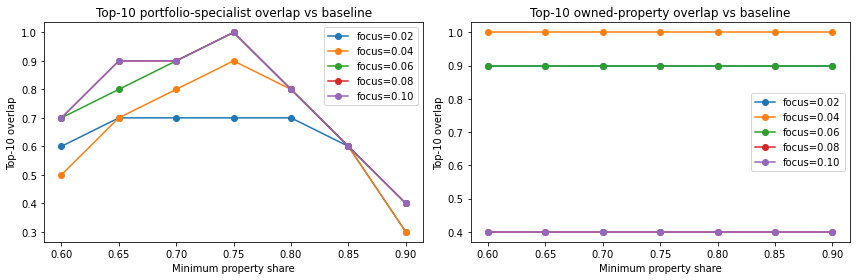


Saved:
- h1_threshold_persistence_summary.csv
- h1_persistent_property_specialists.csv
- h1_persistent_portfolio_specialists.csv
- h1_persistent_owned_properties.csv


In [59]:
# ------------------------------------------------------------
# H1 persistence analysis:
# Do top specialists / top owned properties persist across
# nearby threshold settings?
# ------------------------------------------------------------

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0) Sanity check
# ------------------------------------------------------------
required_cols = {
    "user", "property", "count", "prop_total_edits",
    "property_edit_share", "user_focus_share", "user_total_edits"
}
missing = required_cols - set(leaders.columns)
if missing:
    raise ValueError(f"`leaders` is missing required columns: {missing}")

# ------------------------------------------------------------
# 1) Baseline thresholds
# ------------------------------------------------------------
BASE_MIN_USER_PROPERTY_EDITS = globals().get("OWN_MIN_USER_EDITS", 20)
BASE_MIN_PROPERTY_TOTAL_EDITS = globals().get("OWN_MIN_PROP_TOTAL", 50)
BASE_MIN_PROPERTY_SHARE = globals().get("OWN_MIN_PROP_SHARE", 0.75)
BASE_MIN_USER_FOCUS = globals().get("OWN_MIN_FOCUS", 0.05)

print("Baseline thresholds:")
print({
    "MIN_USER_PROPERTY_EDITS": BASE_MIN_USER_PROPERTY_EDITS,
    "MIN_PROPERTY_TOTAL_EDITS": BASE_MIN_PROPERTY_TOTAL_EDITS,
    "MIN_PROPERTY_SHARE": BASE_MIN_PROPERTY_SHARE,
    "MIN_USER_FOCUS": BASE_MIN_USER_FOCUS,
})

# ------------------------------------------------------------
# 2) Threshold grid
# You can narrow or widen this grid if needed.
# ------------------------------------------------------------
grid_user_property_edits = [10, 20, 50]
grid_property_total_edits = [25, 50, 100]
grid_property_share = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
grid_user_focus = [0.02, 0.04, 0.06, 0.08, 0.10]

# ------------------------------------------------------------
# 3) Helper functions
# ------------------------------------------------------------
def run_owned_analysis(df, min_user_prop_edits, min_prop_total, min_prop_share, min_user_focus):
    owned_pairs = df[
        (df["count"] >= min_user_prop_edits) &
        (df["prop_total_edits"] >= min_prop_total) &
        (df["property_edit_share"] >= min_prop_share) &
        (df["user_focus_share"] >= min_user_focus)
    ].copy()

    if owned_pairs.empty:
        return {
            "owned_pairs": owned_pairs,
            "user_owned": pd.DataFrame(columns=[
                "user", "n_owned_properties", "total_owned_edits",
                "mean_property_share", "median_property_share",
                "mean_user_focus", "max_user_focus",
                "total_user_edits", "owned_edit_fraction"
            ]),
            "property_owned": pd.DataFrame(columns=[
                "property", "n_owners", "total_owned_edits",
                "max_property_share", "mean_property_share",
                "max_user_focus", "mean_user_focus"
            ])
        }

    user_owned = (
        owned_pairs.groupby("user")
        .agg(
            n_owned_properties=("property", "nunique"),
            total_owned_edits=("count", "sum"),
            mean_property_share=("property_edit_share", "mean"),
            median_property_share=("property_edit_share", "median"),
            mean_user_focus=("user_focus_share", "mean"),
            max_user_focus=("user_focus_share", "max"),
            total_user_edits=("user_total_edits", "max"),
        )
        .reset_index()
    )
    user_owned["owned_edit_fraction"] = (
        user_owned["total_owned_edits"] / user_owned["total_user_edits"]
    )

    property_owned = (
        owned_pairs.groupby("property")
        .agg(
            n_owners=("user", "nunique"),
            total_owned_edits=("count", "sum"),
            max_property_share=("property_edit_share", "max"),
            mean_property_share=("property_edit_share", "mean"),
            max_user_focus=("user_focus_share", "max"),
            mean_user_focus=("user_focus_share", "mean"),
        )
        .reset_index()
    )

    return {
        "owned_pairs": owned_pairs,
        "user_owned": user_owned,
        "property_owned": property_owned
    }

def top_k_overlap(a, b, k=10):
    a_top = list(a[:k])
    b_top = list(b[:k])
    if not a_top and not b_top:
        return 1.0
    if not a_top or not b_top:
        return 0.0
    return len(set(a_top) & set(b_top)) / k

def rank_correlation_on_intersection(base_ranked, other_ranked, k=20):
    """
    Spearman-like correlation computed on the intersection of top-k items.
    Returns NaN if fewer than 2 common items.
    """
    base_top = list(base_ranked[:k])
    other_top = list(other_ranked[:k])
    common = list(set(base_top) & set(other_top))
    if len(common) < 2:
        return np.nan

    base_pos = {x: i for i, x in enumerate(base_top)}
    other_pos = {x: i for i, x in enumerate(other_top)}

    x = np.array([base_pos[c] for c in common], dtype=float)
    y = np.array([other_pos[c] for c in common], dtype=float)

    # rank correlation without scipy
    x_rank = pd.Series(x).rank(method="average").to_numpy()
    y_rank = pd.Series(y).rank(method="average").to_numpy()

    x_centered = x_rank - x_rank.mean()
    y_centered = y_rank - y_rank.mean()

    denom = np.sqrt((x_centered**2).sum() * (y_centered**2).sum())
    if denom == 0:
        return np.nan
    return float((x_centered * y_centered).sum() / denom)

def get_rankings(result):
    user_owned = result["user_owned"].copy()
    property_owned = result["property_owned"].copy()

    # Property specialists: exactly 1 owned property
    property_specialists = user_owned[user_owned["n_owned_properties"] == 1].copy()
    property_specialists = property_specialists.sort_values(
        ["owned_edit_fraction", "total_owned_edits", "mean_property_share"],
        ascending=[False, False, False]
    )

    # Portfolio specialists: >= 2 owned properties
    portfolio_specialists = user_owned[user_owned["n_owned_properties"] >= 2].copy()
    portfolio_specialists = portfolio_specialists.sort_values(
        ["owned_edit_fraction", "n_owned_properties", "total_owned_edits", "mean_property_share"],
        ascending=[False, False, False, False]
    )

    # Owned properties ranked by total owned edits, then dominance
    owned_properties = property_owned.sort_values(
        ["total_owned_edits", "max_property_share", "n_owners"],
        ascending=[False, False, True]
    )

    return {
        "property_specialists_df": property_specialists,
        "portfolio_specialists_df": portfolio_specialists,
        "owned_properties_df": owned_properties,
        "property_specialists_ranked": property_specialists["user"].tolist(),
        "portfolio_specialists_ranked": portfolio_specialists["user"].tolist(),
        "owned_properties_ranked": owned_properties["property"].tolist(),
    }

# ------------------------------------------------------------
# 4) Baseline rankings
# ------------------------------------------------------------
baseline_result = run_owned_analysis(
    leaders,
    BASE_MIN_USER_PROPERTY_EDITS,
    BASE_MIN_PROPERTY_TOTAL_EDITS,
    BASE_MIN_PROPERTY_SHARE,
    BASE_MIN_USER_FOCUS,
)
baseline_rankings = get_rankings(baseline_result)

print("\nBaseline sizes:")
print({
    "property_specialists": len(baseline_rankings["property_specialists_ranked"]),
    "portfolio_specialists": len(baseline_rankings["portfolio_specialists_ranked"]),
    "owned_properties": len(baseline_rankings["owned_properties_ranked"]),
})

# ------------------------------------------------------------
# 5) Run persistence analysis over the full grid
# ------------------------------------------------------------
rows = []
appearance_counts_prop_specs = {}
appearance_counts_port_specs = {}
appearance_counts_properties = {}

for min_user_prop_edits, min_prop_total, min_prop_share, min_user_focus in itertools.product(
    grid_user_property_edits,
    grid_property_total_edits,
    grid_property_share,
    grid_user_focus,
):
    result = run_owned_analysis(
        leaders,
        min_user_prop_edits,
        min_prop_total,
        min_prop_share,
        min_user_focus,
    )
    rankings = get_rankings(result)

    # Track appearance counts in top-k across runs
    for u in rankings["property_specialists_ranked"][:10]:
        appearance_counts_prop_specs[u] = appearance_counts_prop_specs.get(u, 0) + 1
    for u in rankings["portfolio_specialists_ranked"][:10]:
        appearance_counts_port_specs[u] = appearance_counts_port_specs.get(u, 0) + 1
    for p in rankings["owned_properties_ranked"][:10]:
        appearance_counts_properties[p] = appearance_counts_properties.get(p, 0) + 1

    row = {
        "min_user_property_edits": min_user_prop_edits,
        "min_property_total_edits": min_prop_total,
        "min_property_share": min_prop_share,
        "min_user_focus": min_user_focus,

        "n_property_specialists": len(rankings["property_specialists_ranked"]),
        "n_portfolio_specialists": len(rankings["portfolio_specialists_ranked"]),
        "n_owned_properties": len(rankings["owned_properties_ranked"]),

        # Top-10 overlap with baseline
        "top10_overlap_property_specialists": top_k_overlap(
            baseline_rankings["property_specialists_ranked"],
            rankings["property_specialists_ranked"],
            k=10
        ),
        "top10_overlap_portfolio_specialists": top_k_overlap(
            baseline_rankings["portfolio_specialists_ranked"],
            rankings["portfolio_specialists_ranked"],
            k=10
        ),
        "top10_overlap_owned_properties": top_k_overlap(
            baseline_rankings["owned_properties_ranked"],
            rankings["owned_properties_ranked"],
            k=10
        ),

        # Top-20 overlap with baseline
        "top20_overlap_property_specialists": top_k_overlap(
            baseline_rankings["property_specialists_ranked"],
            rankings["property_specialists_ranked"],
            k=20
        ),
        "top20_overlap_portfolio_specialists": top_k_overlap(
            baseline_rankings["portfolio_specialists_ranked"],
            rankings["portfolio_specialists_ranked"],
            k=20
        ),
        "top20_overlap_owned_properties": top_k_overlap(
            baseline_rankings["owned_properties_ranked"],
            rankings["owned_properties_ranked"],
            k=20
        ),

        # Rank correlation on intersection
        "rankcorr_property_specialists_top20": rank_correlation_on_intersection(
            baseline_rankings["property_specialists_ranked"],
            rankings["property_specialists_ranked"],
            k=20
        ),
        "rankcorr_portfolio_specialists_top20": rank_correlation_on_intersection(
            baseline_rankings["portfolio_specialists_ranked"],
            rankings["portfolio_specialists_ranked"],
            k=20
        ),
        "rankcorr_owned_properties_top20": rank_correlation_on_intersection(
            baseline_rankings["owned_properties_ranked"],
            rankings["owned_properties_ranked"],
            k=20
        ),
    }
    rows.append(row)

persistence_df = pd.DataFrame(rows).sort_values([
    "min_user_property_edits",
    "min_property_total_edits",
    "min_property_share",
    "min_user_focus"
]).reset_index(drop=True)

print("\nPersistence summary (first 20 rows):")
display(
    persistence_df.head(20).style.format({
        "top10_overlap_property_specialists": "{:.2f}",
        "top10_overlap_portfolio_specialists": "{:.2f}",
        "top10_overlap_owned_properties": "{:.2f}",
        "top20_overlap_property_specialists": "{:.2f}",
        "top20_overlap_portfolio_specialists": "{:.2f}",
        "top20_overlap_owned_properties": "{:.2f}",
        "rankcorr_property_specialists_top20": "{:.2f}",
        "rankcorr_portfolio_specialists_top20": "{:.2f}",
        "rankcorr_owned_properties_top20": "{:.2f}",
    })
)

# ------------------------------------------------------------
# 6) Persistent top items across runs
# ------------------------------------------------------------
n_runs = len(persistence_df)

persistent_property_specialists = (
    pd.DataFrame(
        [{"user": k, "top10_appearances": v, "share_of_runs": v / n_runs}
         for k, v in appearance_counts_prop_specs.items()]
    )
    .sort_values(["top10_appearances", "user"], ascending=[False, True])
    .reset_index(drop=True)
)

persistent_portfolio_specialists = (
    pd.DataFrame(
        [{"user": k, "top10_appearances": v, "share_of_runs": v / n_runs}
         for k, v in appearance_counts_port_specs.items()]
    )
    .sort_values(["top10_appearances", "user"], ascending=[False, True])
    .reset_index(drop=True)
)

persistent_owned_properties = (
    pd.DataFrame(
        [{"property": k, "top10_appearances": v, "share_of_runs": v / n_runs}
         for k, v in appearance_counts_properties.items()]
    )
    .sort_values(["top10_appearances", "property"], ascending=[False, True])
    .reset_index(drop=True)
)

print("\nMost persistent top-10 property specialists across runs:")
display(persistent_property_specialists.head(20))

print("\nMost persistent top-10 portfolio specialists across runs:")
display(persistent_portfolio_specialists.head(20))

print("\nMost persistent top-10 owned properties across runs:")
display(persistent_owned_properties.head(20))

# ------------------------------------------------------------
# 7) Focused pivot plots around baseline count thresholds
# ------------------------------------------------------------
pivot_slice = persistence_df[
    (persistence_df["min_user_property_edits"] == BASE_MIN_USER_PROPERTY_EDITS) &
    (persistence_df["min_property_total_edits"] == BASE_MIN_PROPERTY_TOTAL_EDITS)
].copy()

pivot_port_top10 = pivot_slice.pivot(
    index="min_property_share",
    columns="min_user_focus",
    values="top10_overlap_portfolio_specialists"
)

pivot_prop_top10 = pivot_slice.pivot(
    index="min_property_share",
    columns="min_user_focus",
    values="top10_overlap_owned_properties"
)

print("\nTop-10 overlap of portfolio specialists vs baseline:")
display(pivot_port_top10.style.format("{:.2f}"))

print("\nTop-10 overlap of owned properties vs baseline:")
display(pivot_prop_top10.style.format("{:.2f}"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for focus in sorted(pivot_slice["min_user_focus"].unique()):
    sub = pivot_slice[pivot_slice["min_user_focus"] == focus].sort_values("min_property_share")
    axes[0].plot(
        sub["min_property_share"],
        sub["top10_overlap_portfolio_specialists"],
        marker="o",
        label=f"focus={focus:.2f}"
    )
axes[0].set_title("Top-10 portfolio-specialist overlap vs baseline")
axes[0].set_xlabel("Minimum property share")
axes[0].set_ylabel("Top-10 overlap")
axes[0].legend()

for focus in sorted(pivot_slice["min_user_focus"].unique()):
    sub = pivot_slice[pivot_slice["min_user_focus"] == focus].sort_values("min_property_share")
    axes[1].plot(
        sub["min_property_share"],
        sub["top10_overlap_owned_properties"],
        marker="o",
        label=f"focus={focus:.2f}"
    )
axes[1].set_title("Top-10 owned-property overlap vs baseline")
axes[1].set_xlabel("Minimum property share")
axes[1].set_ylabel("Top-10 overlap")
axes[1].legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8) Optional export
# ------------------------------------------------------------
persistence_df.to_csv("h1_threshold_persistence_summary.csv", index=False)
persistent_property_specialists.to_csv("h1_persistent_property_specialists.csv", index=False)
persistent_portfolio_specialists.to_csv("h1_persistent_portfolio_specialists.csv", index=False)
persistent_owned_properties.to_csv("h1_persistent_owned_properties.csv", index=False)

print("\nSaved:")
print("- h1_threshold_persistence_summary.csv")
print("- h1_persistent_property_specialists.csv")
print("- h1_persistent_portfolio_specialists.csv")
print("- h1_persistent_owned_properties.csv")

In [60]:
# Inspect whether multi-property specialists own related-size portfolios
# and produce a compact table you can discuss qualitatively

# 1) split users into single-property vs portfolio specialists
single_specialists = user_owned[user_owned["n_owned_properties"] == 1].copy()
portfolio_specialists = user_owned[user_owned["n_owned_properties"] >= 2].copy()

print("Counts")
print("single-property specialists:", len(single_specialists))
print("portfolio specialists:", len(portfolio_specialists))

print("\nTop single-property specialists:")
display(
    single_specialists.sort_values(
        ["owned_edit_fraction", "total_owned_edits"],
        ascending=False
    ).head(30)
)

print("\nTop portfolio specialists:")
display(
    portfolio_specialists.sort_values(
        ["n_owned_properties", "owned_edit_fraction", "total_owned_edits"],
        ascending=False
    ).head(30)
)

# 2) bring back all owned pairs for portfolio users
portfolio_pairs = owned_pairs.merge(
    portfolio_specialists[["user", "n_owned_properties", "owned_edit_fraction"]],
    on="user",
    how="inner"
).sort_values(["user", "count"], ascending=[True, False])

print("\nOwned properties for top portfolio specialists:")
display(
    portfolio_pairs[[
        "user", "property", "count", "property_edit_share",
        "user_focus_share", "n_owned_properties", "owned_edit_fraction"
    ]]
    .head(100)
    .style.format({
        "property_edit_share": "{:.3f}",
        "user_focus_share": "{:.3f}",
        "owned_edit_fraction": "{:.3f}",
    })
)

# 3) quick summary stats
summary_specialists = pd.DataFrame({
    "group": ["single-property", "portfolio"],
    "n_users": [len(single_specialists), len(portfolio_specialists)],
    "median_owned_edit_fraction": [
        single_specialists["owned_edit_fraction"].median(),
        portfolio_specialists["owned_edit_fraction"].median()
    ],
    "median_total_owned_edits": [
        single_specialists["total_owned_edits"].median(),
        portfolio_specialists["total_owned_edits"].median()
    ],
    "median_mean_property_share": [
        single_specialists["mean_property_share"].median(),
        portfolio_specialists["mean_property_share"].median()
    ],
})

print("\nSummary by specialist type:")
display(summary_specialists)

Counts
single-property specialists: 333
portfolio specialists: 79

Top single-property specialists:


,user,n_owned_properties,total_owned_edits,mean_property_share,median_property_share,mean_user_focus,max_user_focus,total_user_edits,owned_edit_fraction,top_owned_properties
178,KISTI Data,1,31908,0.981271,0.981271,0.999937,0.999937,31910,0.999937,P13092
171,Jousep Bernhard,1,27146,0.912471,0.912471,0.999374,0.999374,27163,0.999374,P13183
104,Elhuyar Fundazioa,1,3011,0.994714,0.994714,0.999336,0.999336,3013,0.999336,P6838
363,Thomasstjerne,1,2057355,0.973075,0.973075,0.999315,0.999315,2058765,0.999315,P10585
243,Mkbergman,1,55965,0.977281,0.977281,0.999018,0.999018,56020,0.999018,P8408
260,Nonodename,1,5056,0.811166,0.811166,0.999012,0.999012,5061,0.999012,P3347
93,Dr vulpes,1,14090,0.952284,0.952284,0.998795,0.998795,14107,0.998795,P3648
98,Dux Oppositionis,1,805,0.910633,0.910633,0.998759,0.998759,806,0.998759,P11819
147,Hyarion,1,1293,0.851218,0.851218,0.998456,0.998456,1295,0.998456,P11935
262,NtkPrague,1,5459,0.806709,0.806709,0.998354,0.998354,5468,0.998354,P1051



Top portfolio specialists:


,user,n_owned_properties,total_owned_edits,mean_property_share,median_property_share,mean_user_focus,max_user_focus,total_user_edits,owned_edit_fraction,top_owned_properties
151,Ikan,8,14778,0.845073,0.845610,0.114225,0.117178,16172,0.913802,"P11290, P11291, P11289, P11288, P11287"
119,Ghuron,8,78916128,0.996442,0.999568,0.088722,0.217157,111184442,0.709777,"P528, P1215, P3083, P6257, P6258"
304,RPI2026F1,6,27348,0.927223,0.939253,0.065406,0.067817,69688,0.392435,"P12477, P11495, P12427, P11349, P11149"
201,LesserJerome,5,65896,0.998169,0.998505,0.107665,0.114934,122409,0.538326,"P6546, P6544, P6545, P6547, P6543"
364,Tibbs001,5,1530970,0.953498,0.996940,0.071398,0.076946,4288580,0.356988,"P3098, P8363, P1132, P2899, P6153"
3,813gan,4,25614,0.911949,0.897037,0.249698,0.330162,25645,0.998791,"P2132, P2134, P2299, P4010"
411,白布飘扬,4,222572,0.960951,0.963416,0.113517,0.249028,490174,0.454067,"P5753, P5280, P5205, P5475"
30,Arch2all,3,75944,0.941985,0.948632,0.256548,0.396954,98674,0.769645,"P5573, P5383, P5508"
222,Mabschaaf,3,52567,0.913861,0.953962,0.192939,0.466824,90818,0.578817,"P2566, P2062, P10113"
187,Kirilloparma,3,176384,0.922914,0.950435,0.158443,0.225238,371078,0.475329,"P12683, P12001, P5494"



Owned properties for top portfolio specialists:


,user,property,count,property_edit_share,user_focus_share,n_owned_properties,owned_edit_fraction
109,813gan,P2132,8467,0.893,0.330,4,0.999
110,813gan,P2134,7267,0.967,0.283,4,0.999
111,813gan,P2299,4955,0.887,0.193,4,0.999
112,813gan,P4010,4925,0.901,0.192,4,0.999
63,A particle for world to form,P11688,40819,0.939,0.101,3,0.225
64,A particle for world to form,P12570,26759,0.987,0.066,3,0.225
65,A particle for world to form,P7597,23726,0.857,0.059,3,0.225
127,AdrianoRutz,P9157,422102,0.996,0.129,2,0.251
126,AdrianoRutz,P3364,401161,0.995,0.123,2,0.251
165,Arch2all,P5573,39169,0.995,0.397,3,0.770



Summary by specialist type:


,group,n_users,median_owned_edit_fraction,median_total_owned_edits,median_mean_property_share
0,single-property,333,0.178156,4059.0,0.913782
1,portfolio,79,0.346953,37787.0,0.910616


In [61]:
# Sensitivity check for reviewer concern about bot contamination:
# rerun the user-level domination / portfolio analysis after excluding
# the 25 extreme users identified from the entropy filter.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

excluded_users = [
    ".laramar.",
    "Angeldeb82",
    "C1PB8",
    "Daniel Bonin",
    "Elhuyar Fundazioa",
    "Footballdigest",
    "Freakymovie",
    "HeijnaA",
    "Jousep Bernhard",
    "KISTI Data",
    "Ladyartandarchitecture",
    "Lewoniewski",
    "Manducus",
    "Minak",
    "Moiikke",
    "NowItem",
    "Ostapt",
    "Sgerginov",
    "Steinsky",
    "Thomasstjerne",
    "Tpd13",
    "VerifyToday",
    "Vuorje",
    "WT BEE",
    "人造コケッコー",
]

def run_domination_analysis(
    agg,
    excluded_users=None,
    min_user_property_edits=20,
    min_property_total_edits=50,
    own_min_prop_share=0.75,
    own_min_focus=0.05,
):
    excluded_users = set(map(str, excluded_users or []))

    df = agg[["user", "property", "count"]].copy()
    df["user"] = df["user"].astype(str)
    df["property"] = df["property"].astype(str)

    if excluded_users:
        df = df[~df["user"].isin(excluded_users)].copy()

    prop_totals = (
        df.groupby("property")["count"]
          .sum()
          .rename("prop_total_edits")
          .reset_index()
    )
    user_totals = (
        df.groupby("user")["count"]
          .sum()
          .rename("user_total_edits")
          .reset_index()
    )

    up = (
        df.merge(prop_totals, on="property", how="left")
          .merge(user_totals, on="user", how="left")
    )

    up["property_edit_share"] = up["count"] / up["prop_total_edits"]
    up["user_focus_share"] = up["count"] / up["user_total_edits"]

    up = up.sort_values(["property", "count"], ascending=[True, False]).copy()
    up["rank_in_property"] = up.groupby("property").cumcount() + 1

    top1 = up[up["rank_in_property"] == 1].copy()
    top2 = (
        up[up["rank_in_property"] == 2][["property", "count", "user", "property_edit_share"]]
          .rename(columns={
              "count": "second_count",
              "user": "second_user",
              "property_edit_share": "second_property_share"
          })
    )

    leaders = top1.merge(top2, on="property", how="left")
    leaders["second_count"] = leaders["second_count"].fillna(0)
    leaders["second_property_share"] = leaders["second_property_share"].fillna(0)
    leaders["share_gap"] = leaders["property_edit_share"] - leaders["second_property_share"]

    tmp = up[["property", "user", "count"]].copy()
    tmp["p_user_given_property"] = tmp["count"] / tmp.groupby("property")["count"].transform("sum")

    def entropy_norm(x):
        x = np.asarray(x, dtype=float)
        x = x[x > 0]
        if len(x) <= 1:
            return 0.0
        h = -(x * np.log(x)).sum()
        return h / np.log(len(x))

    prop_conc = (
        tmp.groupby("property")["p_user_given_property"]
           .agg(
               property_hhi=lambda x: np.sum(np.asarray(x, dtype=float) ** 2),
               property_entropy_norm=entropy_norm
           )
           .reset_index()
    )
    prop_conc["property_purity_users"] = 1 - prop_conc["property_entropy_norm"]

    leaders = leaders.merge(prop_conc, on="property", how="left")
    leaders["domination_score"] = (
        leaders["property_edit_share"]
        * np.sqrt(leaders["user_focus_share"])
        * np.log1p(leaders["count"])
        * (0.5 + leaders["property_purity_users"])
    )

    cand = leaders[
        (leaders["count"] >= min_user_property_edits) &
        (leaders["prop_total_edits"] >= min_property_total_edits)
    ].copy()

    owned_pairs = cand[
        (cand["property_edit_share"] >= own_min_prop_share) &
        (cand["user_focus_share"] >= own_min_focus)
    ].copy()

    user_owned = (
        owned_pairs.groupby("user")
        .agg(
            n_owned_properties=("property", "nunique"),
            total_owned_edits=("count", "sum"),
            mean_property_share=("property_edit_share", "mean"),
            median_property_share=("property_edit_share", "median"),
            mean_user_focus=("user_focus_share", "mean"),
            max_user_focus=("user_focus_share", "max"),
            total_user_edits=("user_total_edits", "max"),
        )
        .reset_index()
    )

    if len(user_owned) > 0:
        user_owned["owned_edit_fraction"] = user_owned["total_owned_edits"] / user_owned["total_user_edits"]
    else:
        user_owned["owned_edit_fraction"] = pd.Series(dtype=float)

    top_props_per_user = (
        owned_pairs.sort_values(["user", "count"], ascending=[True, False])
        .groupby("user")
        .head(5)
        .groupby("user")["property"]
        .apply(lambda s: ", ".join(map(str, s.tolist())))
        .rename("top_owned_properties")
        .reset_index()
        if len(owned_pairs) > 0 else
        pd.DataFrame(columns=["user", "top_owned_properties"])
    )

    user_owned = user_owned.merge(top_props_per_user, on="user", how="left")

    single_specialists = user_owned[user_owned["n_owned_properties"] == 1].copy()
    portfolio_specialists = user_owned[user_owned["n_owned_properties"] >= 2].copy()

    summary = {
        "n_users_in_agg": df["user"].nunique(),
        "n_properties_in_agg": df["property"].nunique(),
        "n_user_property_rows": len(df),
        "n_candidate_domination_pairs": len(cand),
        "n_owned_pairs": len(owned_pairs),
        "n_specialist_users": len(user_owned),
        "n_single_property_specialists": len(single_specialists),
        "n_portfolio_specialists": len(portfolio_specialists),
        "median_owned_edit_fraction_single": single_specialists["owned_edit_fraction"].median() if len(single_specialists) else np.nan,
        "median_owned_edit_fraction_portfolio": portfolio_specialists["owned_edit_fraction"].median() if len(portfolio_specialists) else np.nan,
        "median_total_owned_edits_single": single_specialists["total_owned_edits"].median() if len(single_specialists) else np.nan,
        "median_total_owned_edits_portfolio": portfolio_specialists["total_owned_edits"].median() if len(portfolio_specialists) else np.nan,
    }

    return {
        "user_owned": user_owned,
        "single_specialists": single_specialists,
        "portfolio_specialists": portfolio_specialists,
        "owned_pairs": owned_pairs,
        "summary": summary,
    }

base = run_domination_analysis(agg, excluded_users=[])
ablated = run_domination_analysis(agg, excluded_users=excluded_users)

metrics = [
    "n_owned_pairs",
    "n_specialist_users",
    "n_single_property_specialists",
    "n_portfolio_specialists",
    "median_owned_edit_fraction_single",
    "median_owned_edit_fraction_portfolio",
    "median_total_owned_edits_single",
    "median_total_owned_edits_portfolio",
]

comparison = pd.DataFrame({
    "metric": metrics,
    "before": [base["summary"][m] for m in metrics],
    "after_excluding_extremes": [ablated["summary"][m] for m in metrics],
})
comparison["abs_change"] = comparison["after_excluding_extremes"] - comparison["before"]
comparison["pct_change"] = 100 * comparison["abs_change"] / comparison["before"].replace(0, np.nan)

print(f"Excluded users: {len(excluded_users)}")
display(
    comparison.style.format({
        "before": "{:,.3f}",
        "after_excluding_extremes": "{:,.3f}",
        "abs_change": "{:,.3f}",
        "pct_change": "{:+.2f}%",
    })
)

print("\nTop specialists BEFORE exclusion:")
display(
    base["user_owned"]
    .sort_values(["n_owned_properties", "owned_edit_fraction", "total_owned_edits"], ascending=False)
    .head(20)
    .style.format({
        "mean_property_share": "{:.3f}",
        "median_property_share": "{:.3f}",
        "mean_user_focus": "{:.3f}",
        "max_user_focus": "{:.3f}",
        "owned_edit_fraction": "{:.3f}",
    })
)

print("\nTop specialists AFTER exclusion:")
display(
    ablated["user_owned"]
    .sort_values(["n_owned_properties", "owned_edit_fraction", "total_owned_edits"], ascending=False)
    .head(20)
    .style.format({
        "mean_property_share": "{:.3f}",
        "median_property_share": "{:.3f}",
        "mean_user_focus": "{:.3f}",
        "max_user_focus": "{:.3f}",
        "owned_edit_fraction": "{:.3f}",
    })
)

Excluded users: 25


,metric,before,after_excluding_extremes,abs_change,pct_change
0,n_owned_pairs,528.000,526.000,-2.000,-0.38%
1,n_specialist_users,412.000,410.000,-2.000,-0.49%
2,n_single_property_specialists,333.000,331.000,-2.000,-0.60%
3,n_portfolio_specialists,79.000,79.000,0.000,+0.00%
4,median_owned_edit_fraction_single,0.178,0.176,-0.002,-1.06%
5,median_owned_edit_fraction_portfolio,0.347,0.347,0.000,+0.00%
6,median_total_owned_edits_single,"4,059.000","3,850.000",-209.000,-5.15%
7,median_total_owned_edits_portfolio,"37,787.000","37,787.000",0.000,+0.00%



Top specialists BEFORE exclusion:


,user,n_owned_properties,total_owned_edits,mean_property_share,median_property_share,mean_user_focus,max_user_focus,total_user_edits,owned_edit_fraction,top_owned_properties
151,Ikan,8,14778,0.845,0.846,0.114,0.117,16172,0.914,"P11290, P11291, P11289, P11288, P11287"
119,Ghuron,8,78916128,0.996,1.000,0.089,0.217,111184442,0.710,"P528, P1215, P3083, P6257, P6258"
304,RPI2026F1,6,27348,0.927,0.939,0.065,0.068,69688,0.392,"P12477, P11495, P12427, P11349, P11149"
201,LesserJerome,5,65896,0.998,0.999,0.108,0.115,122409,0.538,"P6546, P6544, P6545, P6547, P6543"
364,Tibbs001,5,1530970,0.953,0.997,0.071,0.077,4288580,0.357,"P3098, P8363, P1132, P2899, P6153"
3,813gan,4,25614,0.912,0.897,0.250,0.330,25645,0.999,"P2132, P2134, P2299, P4010"
411,白布飘扬,4,222572,0.961,0.963,0.114,0.249,490174,0.454,"P5753, P5280, P5205, P5475"
30,Arch2all,3,75944,0.942,0.949,0.257,0.397,98674,0.770,"P5573, P5383, P5508"
222,Mabschaaf,3,52567,0.914,0.954,0.193,0.467,90818,0.579,"P2566, P2062, P10113"
187,Kirilloparma,3,176384,0.923,0.950,0.158,0.225,371078,0.475,"P12683, P12001, P5494"



Top specialists AFTER exclusion:


,user,n_owned_properties,total_owned_edits,mean_property_share,median_property_share,mean_user_focus,max_user_focus,total_user_edits,owned_edit_fraction,top_owned_properties
152,Ikan,8,14778,0.845,0.846,0.114,0.117,16172,0.914,"P11290, P11291, P11289, P11288, P11287"
120,Ghuron,8,78916128,0.996,1.000,0.089,0.217,111184442,0.710,"P528, P1215, P3083, P6257, P6258"
303,RPI2026F1,6,27348,0.927,0.939,0.065,0.068,69688,0.392,"P12477, P11495, P12427, P11349, P11149"
200,LesserJerome,5,65896,0.998,0.999,0.108,0.115,122409,0.538,"P6546, P6544, P6545, P6547, P6543"
362,Tibbs001,5,1530970,0.953,0.997,0.071,0.077,4288580,0.357,"P3098, P8363, P1132, P2899, P6153"
3,813gan,4,25614,0.912,0.897,0.250,0.330,25645,0.999,"P2132, P2134, P2299, P4010"
409,白布飘扬,4,222572,0.961,0.963,0.114,0.249,490174,0.454,"P5753, P5280, P5205, P5475"
30,Arch2all,3,75944,0.942,0.949,0.257,0.397,98674,0.770,"P5573, P5383, P5508"
221,Mabschaaf,3,52567,0.914,0.954,0.193,0.467,90818,0.579,"P2566, P2062, P10113"
186,Kirilloparma,3,176384,0.923,0.950,0.158,0.225,371078,0.475,"P12683, P12001, P5494"


## Exporting results

In [64]:
filter_summary

,stage,rows,users,properties,total_edits,rows_removed,rows_removed_pct,users_removed,users_removed_pct,properties_removed,properties_removed_pct,total_edits_removed,total_edits_removed_pct
0,raw,4352804,853511,12730,1.653318e+09,0,0.000000,0,0.000000,0,0.000000,0.000000e+00,0.000000
1,after_ip_filter,2726263,178797,12711,1.648717e+09,1626541,37.367660,674714,79.051588,19,0.149254,4.601235e+06,0.278303
2,after_bot_filter,2704658,178108,12703,6.256845e+08,1648146,37.864007,675403,79.132313,27,0.212097,1.027634e+09,62.155832
3,after_min_property_users,2697218,178093,9667,6.240004e+08,1655586,38.034931,675418,79.134071,3063,24.061273,1.029318e+09,62.257690
4,after_min_user_edits,2617487,111362,9667,6.239133e+08,1735317,39.866647,742149,86.952482,3063,24.061273,1.029405e+09,62.262958
5,after_min_distinct_properties_per_user,2610544,104419,9667,6.236344e+08,1742260,40.026153,749092,87.765946,3063,24.061273,1.029684e+09,62.279833


In [65]:
compact_filter_report

,stage,users,users_removed_pct,properties,properties_removed_pct,rows,rows_removed_pct,total_edits,total_edits_removed_pct
0,raw,853511,0.000000,12730,0.000000,4352804,0.000000,1.653318e+09,0.000000
1,after_ip_filter,178797,79.051588,12711,0.149254,2726263,37.367660,1.648717e+09,0.278303
2,after_bot_filter,178108,79.132313,12703,0.212097,2704658,37.864007,6.256845e+08,62.155832
3,after_min_property_users,178093,79.134071,9667,24.061273,2697218,38.034931,6.240004e+08,62.257690
4,after_min_user_edits,111362,86.952482,9667,24.061273,2617487,39.866647,6.239133e+08,62.262958
5,after_min_distinct_properties_per_user,104419,87.765946,9667,24.061273,2610544,40.026153,6.236344e+08,62.279833


In [66]:
filter_summary.to_csv("exports/h1_filter_summary.csv", index=False)
compact_filter_report.to_csv("exports/h1_filter_summary_compact.csv", index=False)

In [67]:
owned_pairs.to_csv("exports/h1_owned_pairs.csv", index=False)

In [69]:
owned_pairs

,min_user_property_edits,min_property_total_edits,min_property_share,min_user_focus,n_property_specialists,n_portfolio_specialists,n_owned_properties,top10_overlap_property_specialists,top10_overlap_portfolio_specialists,top10_overlap_owned_properties,top20_overlap_property_specialists,top20_overlap_portfolio_specialists,top20_overlap_owned_properties,rankcorr_property_specialists_top20,rankcorr_portfolio_specialists_top20,rankcorr_owned_properties_top20
144,20,50,0.60,0.1,342,50,458,0.9,0.7,0.4,0.90,0.75,0.60,1.0,0.964286,1.0
149,20,50,0.65,0.1,321,43,421,0.9,0.9,0.4,0.90,0.80,0.60,1.0,0.970588,1.0
154,20,50,0.70,0.1,290,38,378,0.9,0.9,0.4,0.95,0.75,0.60,1.0,1.000000,1.0
159,20,50,0.75,0.1,266,34,345,1.0,1.0,0.4,1.00,0.70,0.60,1.0,1.000000,1.0
164,20,50,0.80,0.1,236,28,303,1.0,0.8,0.4,1.00,0.60,0.60,1.0,1.000000,1.0
169,20,50,0.85,0.1,211,21,258,0.8,0.6,0.4,0.80,0.55,0.60,1.0,0.590909,1.0
174,20,50,0.90,0.1,171,14,200,0.7,0.4,0.4,0.65,0.35,0.45,1.0,0.464286,1.0


In [70]:
user_owned

,user,n_owned_properties,total_owned_edits,mean_property_share,median_property_share,mean_user_focus,max_user_focus,total_user_edits,owned_edit_fraction,top_owned_properties
0,-sasha-,1,20090,0.855512,0.855512,0.771594,0.771594,26037,0.771594,P1991
1,4b3eff,1,276,0.854489,0.854489,0.154104,0.154104,1791,0.154104,P11816
2,4ing,1,106657,0.879566,0.879566,0.608846,0.608846,175179,0.608846,P8707
3,813gan,4,25614,0.911949,0.897037,0.249698,0.330162,25645,0.998791,"P2132, P2134, P2299, P4010"
4,85jesse,1,499,0.972710,0.972710,0.070212,0.070212,7107,0.070212,P10865
...,...,...,...,...,...,...,...,...,...,...
407,זאב קטן,1,3554,0.804072,0.804072,0.642328,0.642328,5533,0.642328,P3959
408,عمر,1,50,0.862069,0.862069,0.303030,0.303030,165,0.303030,P10582
409,何三（S）,1,14621,0.844412,0.844412,0.750180,0.750180,19490,0.750180,P5400
410,本日晴天,1,206030,0.982480,0.982480,0.436054,0.436054,472487,0.436054,P11496


In [71]:
user_owned.to_csv("exports/h1_user_owned_summary.csv", index=False)

In [72]:
single_specialists.to_csv("exports/h1_single_property_specialists.csv", index=False)
portfolio_specialists.to_csv("exports/h1_portfolio_specialists.csv", index=False)
portfolio_pairs.to_csv("exports/h1_portfolio_owned_pairs.csv", index=False)
summary_specialists.to_csv("exports/h1_specialist_type_summary.csv", index=False)

In [75]:
sensitivity_df.to_csv("exports/h1_threshold_sensitivity_summary.csv", index=False)

In [76]:
sensitivity_df

,min_user_property_edits,min_property_total_edits,min_property_share,min_user_focus,n_owned_pairs,n_editors_with_owned,n_property_specialists,n_portfolio_specialists,median_owned_edit_fraction_property,median_owned_edit_fraction_portfolio,median_mean_property_share_property,median_mean_property_share_portfolio,jaccard_property_specialists_vs_baseline,jaccard_portfolio_specialists_vs_baseline,portfolio_stronger_by_fraction
0,10,25,0.6,0.02,1174,735,519,216,0.119741,0.224680,0.850210,0.860710,0.436762,0.365741,True
1,10,25,0.6,0.04,829,590,453,137,0.158617,0.293406,0.858511,0.857756,0.597561,0.576642,True
2,10,25,0.6,0.06,648,508,418,90,0.194444,0.347963,0.862820,0.859491,0.632609,0.625000,True
3,10,25,0.6,0.08,534,441,371,70,0.241598,0.373172,0.867824,0.876411,0.564444,0.552083,True
4,10,25,0.6,0.10,459,393,343,50,0.273269,0.436899,0.872177,0.869013,0.529412,0.417582,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,30,100,0.9,0.02,506,353,264,89,0.106011,0.198532,0.963440,0.972364,0.394860,0.377049,True
416,30,100,0.9,0.04,354,274,221,53,0.149729,0.329727,0.966571,0.967678,0.469496,0.466667,True
417,30,100,0.9,0.06,278,234,204,30,0.197745,0.348594,0.965571,0.971001,0.463215,0.379747,True
418,30,100,0.9,0.08,228,203,181,22,0.247677,0.348594,0.966975,0.980213,0.396739,0.278481,True


In [77]:
persistence_df.to_csv("exports/h1_threshold_persistence_summary.csv", index=False)

In [78]:
persistent_property_specialists.to_csv("exports/h1_persistent_property_specialists.csv", index=False)
persistent_portfolio_specialists.to_csv("exports/h1_persistent_portfolio_specialists.csv", index=False)
persistent_owned_properties.to_csv("exports/h1_persistent_owned_properties.csv", index=False)

In [80]:
persistence_df.dtypes

min_user_property_edits                   int64
min_property_total_edits                  int64
min_property_share                      float64
min_user_focus                          float64
n_property_specialists                    int64
n_portfolio_specialists                   int64
n_owned_properties                        int64
top10_overlap_property_specialists      float64
top10_overlap_portfolio_specialists     float64
top10_overlap_owned_properties          float64
top20_overlap_property_specialists      float64
top20_overlap_portfolio_specialists     float64
top20_overlap_owned_properties          float64
rankcorr_property_specialists_top20     float64
rankcorr_portfolio_specialists_top20    float64
rankcorr_owned_properties_top20         float64
dtype: object

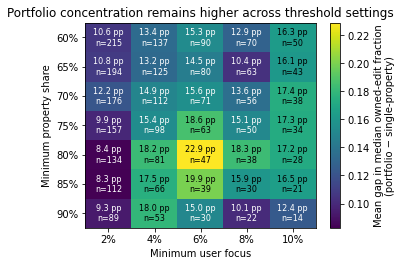

In [85]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Input
input_path = Path("exports/h1_threshold_sensitivity_summary.csv")
output_dir = Path("figures")
output_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(input_path)

# Compute the gap we want to visualize
df["gap_portfolio_minus_single"] = (
    df["median_owned_edit_fraction_portfolio"]
    - df["median_owned_edit_fraction_property"]
)

# Aggregate over the two count thresholds:
# min_user_property_edits and min_property_total_edits
agg = (
    df.groupby(["min_property_share", "min_user_focus"], as_index=False)
      .agg(
          mean_gap=("gap_portfolio_minus_single", "mean"),
          mean_portfolio_n=("n_portfolio_specialists", "mean"),
          min_gap=("gap_portfolio_minus_single", "min"),
          max_gap=("gap_portfolio_minus_single", "max"),
      )
)

# Pivot for plotting
heat_gap = agg.pivot(
    index="min_property_share",
    columns="min_user_focus",
    values="mean_gap"
).sort_index(ascending=True)

heat_n = agg.pivot(
    index="min_property_share",
    columns="min_user_focus",
    values="mean_portfolio_n"
).reindex(index=heat_gap.index, columns=heat_gap.columns)

# Plot
fig, ax = plt.subplots(figsize=(5.2, 3.8))

im = ax.imshow(heat_gap.values, aspect="auto")

# Axis ticks and labels
ax.set_xticks(np.arange(len(heat_gap.columns)))
ax.set_xticklabels([f"{x:.0%}" for x in heat_gap.columns])

ax.set_yticks(np.arange(len(heat_gap.index)))
ax.set_yticklabels([f"{y:.0%}" for y in heat_gap.index])

ax.set_xlabel("Minimum user focus")
ax.set_ylabel("Minimum property share")
ax.set_title("Portfolio concentration remains higher across threshold settings")

# Annotate each cell:
# first line = mean gap in percentage points
# second line = mean number of portfolio specialists
midpoint = (np.nanmin(heat_gap.values) + np.nanmax(heat_gap.values)) / 2

for i in range(heat_gap.shape[0]):
    for j in range(heat_gap.shape[1]):
        gap = heat_gap.iloc[i, j]
        n_port = heat_n.iloc[i, j]
        label = f"{gap*100:.1f} pp\nn={n_port:.0f}"
        text_color = "white" if gap < midpoint else "black"
        ax.text(j, i, label, ha="center", va="center", fontsize=8, color=text_color)
        
        
# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Mean gap in median owned-edit fraction\n(portfolio − single-property)")

fig.tight_layout()

fig.savefig(output_dir / "h1_threshold_sensitivity.pdf", bbox_inches="tight")
fig.savefig(output_dir / "h1_threshold_sensitivity.png", dpi=300, bbox_inches="tight")